# Proyecto Integrador — Parte I
## KDD, EDA y Procesamiento Distribuido con Apache Spark

**Curso:** Minería de Datos Masivos y Flujos de Datos
**Dataset:** Contrataciones Abiertas del Perú, 2025 — estándar OCDS (Open Contracting Data Standard)

**Fuente de datos (citada explícitamente):**
- Contrataciones Abiertas OCDS — OECE/OSCE: <https://contratacionesabiertas.osce.gob.pe/>
- Registro OCDS Perú (descarga masiva): <https://data.open-contracting.org/es/publication/135>

Los 12 archivos JSON (uno por mes de 2025) se descargan con `python3 download/download.py`
y quedan en `data/`.

---

### Contenido

| Sección | Contenido | Requisito del enunciado |
|---|---|---|
| 0 | Preguntas de interés y justificación del dataset | Preguntas propias no descriptivas |
| 1 | KDD · Selección | Describir el proceso KDD |
| 2 | KDD · Preprocesamiento (nulos, duplicados, inconsistencias) | Documentar la limpieza |
| 3 | KDD · Transformación y esquema final en Spark | Esquema final usado en Spark |
| 4 | EDA con Spark DataFrames y Spark SQL | Temporal, categóricas, montos, entidades |
| 5 | Agregaciones: RDD (MapReduce) vs DataFrame vs Spark SQL | Dos agregaciones en ambos estilos |
| 6 | Particionamiento y plan de ejecución | Cómo particiona y cómo afecta al plan |
| 7 | Exportación de artefactos para el reporte web | Paso de exportación |
| 8 | Conclusiones de la Parte I | Interpretación |

## 0. Preguntas de interés y justificación del dataset

### 0.1 Por qué este dataset

El enunciado pide cuatro condiciones mínimas. El registro OCDS de contrataciones peruanas las cumple:

| Criterio exigido | Cómo lo cumple este dataset |
|---|---|
| **Volumen** para justificar procesamiento distribuido | ~12 archivos JSON anidados de varios cientos de MB en total; el parseo de JSON multilínea y las agregaciones por entidad/proveedor son costosas en un solo hilo. |
| **Campos representables como conjuntos o vectores** | Cada proceso tiene ítems con clasificación UNSPSC y un título en texto libre → conjunto de códigos UNSPSC o shingles del título (Parte II), y TF-IDF sobre el título (Parte III). |
| **Dimensión temporal** | Cada release trae `date`, `tender.tenderPeriod` y `awards.date` → permite ordenar y simular llegada secuencial (Parte IV). |
| **Estructura transaccional natural** | Un proceso es literalmente una canasta: `{entidad, método, categoría, región, tramo de monto, códigos UNSPSC}` → transacciones para Apriori/FP-Growth (Parte V). |

Además es un dataset con relevancia pública directa: la compra pública peruana representa una fracción
importante del gasto del Estado y su análisis alimenta debates reales de transparencia.

### 0.2 Preguntas de interés

Deliberadamente **no descriptivas**: cada una es una hipótesis contrastable, no un conteo.

> **P1 — Competencia.** ¿La concurrencia de postores cae sistemáticamente conforme crece el monto
> del proceso? Si los contratos grandes atraen *menos* competencia que los pequeños, eso invierte lo
> que esperaría un mercado sano y apunta a barreras de entrada o a requisitos de calificación
> restrictivos. **Relevancia:** menos competencia se asocia empíricamente a precios más altos.

> **P2 — Concentración.** ¿Hay entidades cuyo gasto se concentra en muy pocos proveedores, más allá
> de lo que explicaría la naturaleza técnica de lo que compran? Se mide con el índice
> Herfindahl-Hirschman (HHI) por entidad. **Relevancia:** la concentración persistente entidad-proveedor
> es uno de los indicadores de riesgo (*red flags*) que usa la literatura de contrataciones abiertas.

> **P3 — Estacionalidad presupuestal.** ¿El gasto se acumula al cierre del año fiscal? En el ciclo
> presupuestal peruano los saldos no ejecutados no se arrastran, lo que incentiva a gastar en el
> último trimestre. **Relevancia:** la compra apurada de fin de año suele tener menos competencia y
> peor planificación; si el patrón existe, debería verse acompañado de mayor uso de métodos
> excepcionales como la contratación directa.

### 0.3 Cómo alimenta esta parte a las siguientes

| Producto de la Parte I | Se reutiliza en |
|---|---|
| Tabla `releases` limpia en Parquet | Partes II, III, IV y V |
| Conjunto de códigos UNSPSC por proceso | Parte II (Jaccard / MinHash / LSH) |
| Título normalizado del proceso | Parte II (shingling) y Parte III (TF-IDF) |
| Serie ordenada por `date` | Parte IV (simulación del flujo) |
| Canasta `{entidad, método, categoría, región, tramo, UNSPSC}` | Parte V (FP-Growth) |

---
## Configuración del entorno

**Requisitos:** Java 17 (PySpark 3.5 no soporta oficialmente Java 21+) y
`pip install pyspark==3.5.3 pandas matplotlib pyarrow`.

In [1]:
import os, sys, json, time, shutil, warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import pyspark
from pyspark.sql import SparkSession, DataFrame, Window
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StructType, NumericType

%matplotlib inline
plt.rcParams.update({"figure.autolayout": True, "axes.grid": True, "grid.alpha": .3,
                     "figure.dpi": 110, "font.size": 9})
warnings.filterwarnings("ignore", message=".*Arrow optimization.*")
pd.set_option("display.max_columns", 60, "display.width", 200)

# --- Rutas del proyecto (el notebook vive en la raíz del repo) ---------------
ROOT        = Path.cwd()
DATA_DIR    = ROOT / "data"            # JSON crudos (los genera download/download.py)
PARQUET_DIR = ROOT / "parquet"         # data aplanada y limpia
OUT_DIR     = ROOT / "outputs" / "eda"
TABLES_DIR  = OUT_DIR / "tables"       # CSV por hallazgo
FIG_DIR     = OUT_DIR / "figures"      # PNG
WEB_DIR     = ROOT / "outputs" / "web" # artefactos para el reporte interactivo
for d in (PARQUET_DIR, TABLES_DIR, FIG_DIR, WEB_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Python  :", sys.version.split()[0])
print("PySpark :", pyspark.__version__)
print("Data    :", DATA_DIR, "->", len(list(DATA_DIR.glob("*.json"))), "archivos JSON")

Python  : 3.11.8
PySpark : 3.5.0
Data    : /home/jovyan/work/data -> 12 archivos JSON


In [2]:
# El intérprete del venv debe ser el mismo en driver y workers, si no Spark
# aborta con "Python worker has different version".
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
os.environ.setdefault("PYSPARK_DRIVER_PYTHON", sys.executable)
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-memory 5g pyspark-shell"
spark = (
    SparkSession.builder
    .appName("ProyectoIntegrador-ParteI-EDA")
    .master("local[*]")
    # El JSON multilínea NO es divisible: cada archivo cae en una sola tarea y
    # debe caber en memoria al parsearse. De ahí la holgura en el driver.
    .config("spark.driver.memory", "8g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.sql.session.timeZone", "America/Lima")
    .config("spark.sql.caseSensitive", "false")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "true")
    .config("spark.sql.parquet.compression.codec", "snappy")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark {spark.version} | master={spark.sparkContext.master} | "
      f"cores={spark.sparkContext.defaultParallelism}")
print("shuffle.partitions =", spark.conf.get("spark.sql.shuffle.partitions"))

Spark 3.5.0 | master=local[*] | cores=16
shuffle.partitions = 64


In [3]:
# --------------------------------------------------------------------------- #
# Utilidades usadas en todo el notebook
# --------------------------------------------------------------------------- #
def schema_paths(schema, prefix=""):
    """Rutas del esquema en notación de punto. Los arrays de structs se
    recorren como structs, así 'awards.value.amount' aparece aunque
    'awards' sea un array."""
    out = []
    for f_ in schema.fields:
        p = f"{prefix}{f_.name}"
        out.append(p)
        dt = f_.dataType
        if isinstance(dt, StructType):
            out += schema_paths(dt, p + ".")
        elif isinstance(dt, ArrayType) and isinstance(dt.elementType, StructType):
            out += schema_paths(dt.elementType, p + ".")
    return out

def has_path(df, path):
    """True si la ruta existe en el esquema (case-insensitive)."""
    return path.lower() in {p.lower() for p in schema_paths(df.schema)}

def safe_col(df, path, alias, cast="string"):
    """Columna si existe; columna nula tipada si no. Los campos OCDS son
    opcionales y pueden faltar en algunos meses: sin esto el notebook
    reventaría a mitad del pipeline."""
    if has_path(df, path):
        return F.col(path).cast(cast).alias(alias)
    return F.lit(None).cast(cast).alias(alias)

def parse_ocds_date(col):
    """'2025-03-14T09:15:00-05:00' -> timestamp. Se recorta a 19 caracteres
    para ignorar el offset y los milisegundos, que varían entre publicadores."""
    c = F.col(col) if isinstance(col, str) else col
    return F.to_timestamp(F.substring(c.cast("string"), 1, 19), "yyyy-MM-dd'T'HH:mm:ss")

def guardar(df_or_pdf, nombre, limite=5000):
    """Materializa un resultado AGREGADO y lo guarda como CSV.

    Sólo se usa con salidas ya reducidas (decenas o cientos de filas). El
    dataset completo nunca se trae al driver."""
    pdf = df_or_pdf if isinstance(df_or_pdf, pd.DataFrame) else df_or_pdf.limit(limite).toPandas()
    pdf.to_csv(TABLES_DIR / f"{nombre}.csv", index=False, encoding="utf-8-sig")
    return pdf

def fig(nombre):
    """Guarda la figura activa en outputs/eda/figures y la muestra."""
    plt.savefig(FIG_DIR / f"{nombre}.png", dpi=140, bbox_inches="tight")
    plt.show()

def barh(pdf, col_cat, col_val, titulo, xlabel, nombre, top=15, color="#2b6cb0"):
    d = pdf.head(top).iloc[::-1]
    plt.figure(figsize=(8, max(2.8, .34 * len(d))))
    plt.barh(d[col_cat].astype(str).str.slice(0, 45), d[col_val], color=color)
    plt.title(titulo); plt.xlabel(xlabel)
    fig(nombre)

def cronometrar(nombre, fn, repeticiones=3):
    """Ejecuta fn() varias veces y devuelve el mejor tiempo.

    Se toma el MÍNIMO y no el promedio: en una JVM el primer pase incluye
    compilación JIT y calentamiento de caché, ruido que no pertenece al
    algoritmo que queremos medir."""
    tiempos = []
    for _ in range(repeticiones):
        t0 = time.perf_counter()
        r = fn()
        tiempos.append(time.perf_counter() - t0)
    print(f"  {nombre:<34} mejor={min(tiempos):6.2f}s  peor={max(tiempos):6.2f}s")
    return min(tiempos), r

print("Utilidades cargadas.")

Utilidades cargadas.


In [4]:
print("Heap driver:", spark.sparkContext._jvm.java.lang.Runtime.getRuntime().maxMemory()/1024**3, "GB")


Heap driver: 5.0 GB


In [5]:
import os
tot = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 1024**3
print(f"RAM del contenedor: {tot:.1f} GB")
print("Heap driver: 10.0 GB")

RAM del contenedor: 7.4 GB
Heap driver: 10.0 GB


---
# 1. KDD · Etapa de Selección

El proceso KDD (*Knowledge Discovery in Databases*) que se sigue en este notebook:

| Etapa KDD | Qué se hace aquí | Sección |
|---|---|---|
| **Selección** | Elegir la fuente OCDS, los 12 meses de 2025 y decidir qué campos del estándar son relevantes para P1–P3. | 1 |
| **Preprocesamiento** | Nulos, duplicados, inconsistencias de moneda y de fechas, valores imposibles. | 2 |
| **Transformación** | Aplanar el JSON anidado a tablas relacionales, derivar variables (tramo de monto, postor único, ratio adjudicado) y persistir en Parquet. | 3 |
| **Minería** | EDA y agregaciones distribuidas que responden a P1–P3. | 4–5 |
| **Interpretación / Evaluación** | Lectura de cada hallazgo en el contexto de la compra pública peruana. | 4–8 |

## 1.1 Estructura del paquete OCDS

Un archivo OCDS puede venir en tres envoltorios distintos. El código los detecta en vez de asumir uno:

- **Release package** — objeto con una lista `releases` (lo habitual en el publicador peruano).
- **Record package** — objeto con `records`, cada uno con `compiledRelease`.
- **Arreglo plano** de releases sin envoltorio.

In [6]:
archivos = sorted(DATA_DIR.glob("*.json"), key=lambda p: (len(p.stem), p.stem))
assert archivos, f"No hay JSON en {DATA_DIR}. Ejecuta primero: python3 download/download.py"

tam_mb = sum(f.stat().st_size for f in archivos) / 1024**2
print(f"{len(archivos)} archivos | {tam_mb:,.1f} MB en disco")
for f_ in archivos[:3]:
    print(f"  {f_.name:>10}  {f_.stat().st_size/1024**2:8.1f} MB")
print("  ...")

12 archivos | 1,400.9 MB en disco
      1.json      22.4 MB
      2.json      88.7 MB
      3.json     140.8 MB
  ...


In [7]:
t0 = time.perf_counter()

# multiLine=True: cada archivo es UN objeto JSON, no JSON-Lines.
# mode=PERMISSIVE: un registro corrupto no aborta la lectura completa.
raw = (spark.read
       .option("multiLine", "true")
       .option("mode", "PERMISSIVE")
       .json([str(f_) for f_ in archivos]))

print(f"Lectura + inferencia de esquema: {time.perf_counter()-t0:.1f}s")
print("\nColumnas de primer nivel del paquete:")
for f_ in raw.schema.fields:
    print(f"  {f_.name:<18} {f_.dataType.simpleString()[:70]}")

Lectura + inferencia de esquema: 9.2s

Columnas de primer nivel del paquete:
  extensions         array<string>
  license            string
  publicationPolicy  string
  publishedDate      string
  publisher          struct<name:string>
  records            array<struct<compiledRelease:struct<awards:array<struct<date:string,id
  uri                string
  version            string


In [8]:
# --- Normalización del envoltorio -> 1 fila por release --------------------- #
top = {f_.name.lower() for f_ in raw.schema.fields}

if "releases" in top:
    formato = "release package"
    releases_raw = raw.select(F.explode("releases").alias("r")).select("r.*")
elif "records" in top:
    formato = "record package"
    rec = raw.select(F.explode("records").alias("rec"))
    if has_path(rec, "rec.compiledRelease"):
        releases_raw = rec.select("rec.compiledRelease.*")
    else:
        releases_raw = rec.select(F.explode("rec.releases").alias("r")).select("r.*")
elif "ocid" in top:
    formato = "arreglo plano de releases"
    releases_raw = raw
else:
    raise ValueError(f"Envoltorio no reconocido. Columnas: {sorted(top)}")

print(f"Formato detectado: {formato}\n")
print("Esquema de un release (primer nivel):")
for f_ in releases_raw.schema.fields:
    print(f"  {f_.name:<18} {f_.dataType.simpleString()[:90]}")

n_releases = releases_raw.count()
print(f"\nReleases totales: {n_releases:,}")

Formato detectado: record package

Esquema de un release (primer nivel):
  awards             array<struct<date:string,id:string,items:array<struct<additionalClassifications:array<stru
  buyer              struct<id:string,name:string>
  contracts          array<struct<awardID:string,dateSigned:string,description:string,documents:array<struct<da
  dataSegmentation   struct<criteria:array<string>,id:string>
  date               string
  id                 string
  initiationType     string
  ocid               string
  parties            array<struct<additionalIdentifiers:array<struct<id:string,legalName:string,scheme:string>>
  planning           struct<budget:struct<amount:struct<amount:double,currency:string,currencyName:string>,desc
  publishedDate      string
  sources            array<struct<id:string,name:string,url:string>>
  tag                array<string>
  tender             struct<additionalProcurementCategories:array<string>,datePublished:string,description:stri

Releases 

### Campos seleccionados y por qué

De las decenas de campos del estándar OCDS se retienen los que sostienen P1–P3 y los que alimentan
las Partes II–V. Descartar el resto no es un detalle cosmético: reduce el volumen que viaja por la
red en cada *shuffle*.

| Bloque OCDS | Campos retenidos | Para qué |
|---|---|---|
| Identificación | `ocid`, `id`, `date` | Llave y eje temporal (P3, Parte IV) |
| Comprador | `buyer.*`, `parties[].address.region` | Entidad y brecha territorial (P2) |
| Proceso | `tender.procurementMethodDetails`, `mainProcurementCategory`, `status`, `value`, `numberOfTenderers` | Competencia y montos (P1, P3) |
| Adjudicación | `awards[].value`, `awards[].suppliers[]` | Concentración de proveedores (P2) |
| Contratos | `contracts[].value`, `dateSigned` | Monto efectivamente contratado |
| Ítems | `tender.items[].classification` | Conjuntos UNSPSC (Partes II, III, V) |

---
# 2. KDD · Etapa de Transformación

El JSON OCDS es profundamente anidado (arrays dentro de structs dentro de arrays). Spark puede
consultarlo así, pero cada acceso a `awards.value.amount` implica recorrer el array completo.
Se aplana a **cuatro tablas relacionales**:

| Tabla | Granularidad | Uso |
|---|---|---|
| `releases` | 1 fila por proceso | Tabla principal del EDA |
| `awards` | 1 fila por adjudicación | Montos y proveedores (P2) |
| `items` | 1 fila por ítem | Códigos UNSPSC (Partes II, III, V) |
| `parties` | 1 fila por (proceso, actor, rol) | Región y roles |

In [9]:
# --------------------------------------------------------------------------- #
# Expresiones auxiliares sobre arrays
# --------------------------------------------------------------------------- #

def suma_montos(arr):
    """Suma value.amount de un array OCDS devolviendo NULL si no hay ningún valor.

    Un aggregate() con acumulador 0 devolvería 0.0 sobre un array vacío, y un
    proceso SIN adjudicación entraría al análisis como 'monto cero' en lugar de
    'monto desconocido'. Eso hunde los promedios y contamina los conteos de
    ceros en los chequeos de calidad. Se arranca el acumulador en NULL."""
    return F.expr(
        f"aggregate("
        f"  filter(transform({arr}, x -> x.value.amount), a -> a is not null),"
        f"  CAST(NULL AS DOUBLE),"
        f"  (acc, x) -> coalesce(acc, CAST(0 AS DOUBLE)) + x)"
    )

# Región: se busca entre las 'parties' la que tenga rol buyer o procuringEntity.
if has_path(releases_raw, "parties.roles") and has_path(releases_raw, "parties.address.region"):
    region_expr = F.element_at(F.expr(
        "filter(transform(parties, p -> "
        "  CASE WHEN array_contains(p.roles,'buyer') "
        "         OR array_contains(p.roles,'procuringEntity') "
        "       THEN p.address.region ELSE NULL END), x -> x is not null)"), 1)
elif has_path(releases_raw, "parties.address.region"):
    region_expr = F.element_at(F.col("parties.address.region"), 1)
else:
    region_expr = F.lit(None)

# --------------------------------------------------------------------------- #
# EJE TEMPORAL
# --------------------------------------------------------------------------- #
# El diagnóstico sobre la data real mostró que 'date' del compiledRelease es la
# fecha de última ACTUALIZACIÓN del registro, no la del proceso: sólo un 75% cae
# en 2025 y el rango llega hasta 2026. El campo correcto es
# tender.tenderPeriod.startDate (6% de nulos, 94% en 2025). Se arma una cascada
# y se deja constancia de qué fuente alimentó cada fila.
_cands = [
    ("tenderPeriod", "tender.tenderPeriod.startDate"),
    ("award",        None),   # se resuelve abajo (está dentro de un array)
    ("release_date", "date"),
]
fecha_tp = (parse_ocds_date("tender.tenderPeriod.startDate")
            if has_path(releases_raw, "tender.tenderPeriod.startDate") else F.lit(None).cast("timestamp"))
fecha_aw = (parse_ocds_date(F.element_at(F.col("awards.date"), 1))
            if has_path(releases_raw, "awards.date") else F.lit(None).cast("timestamp"))
fecha_rd = (parse_ocds_date("date") if has_path(releases_raw, "date")
            else F.lit(None).cast("timestamp"))

fecha_expr  = F.coalesce(fecha_tp, fecha_aw, fecha_rd)
fuente_expr = (F.when(fecha_tp.isNotNull(), "tenderPeriod.startDate")
                .when(fecha_aw.isNotNull(), "awards.date")
                .when(fecha_rd.isNotNull(), "release.date"))

# --------------------------------------------------------------------------- #
# CLASIFICACIÓN DE ÍTEMS
# --------------------------------------------------------------------------- #
# Dos catálogos conviven en la data peruana:
#   classification            -> CUBSO, 16 dígitos, ~10 700 códigos distintos
#   additionalClassifications -> UNSPSC, 8 dígitos, ~3 780 códigos distintos
# CUBSO es tan específico que dos procesos casi nunca comparten código: para
# similitud de conjuntos es inservible. El UNSPSC, y sobre todo su prefijo de
# 4 dígitos (la 'familia', ~359 valores), sí agrupa.
def _codigos(esquema):
    return F.expr(f"""
        filter(array_distinct(flatten(transform(
            coalesce(tender.items, array()),
            i -> coalesce(
                    transform(filter(coalesce(i.additionalClassifications, array()),
                                     c -> upper(c.scheme) = '{esquema}'), c -> c.id),
                    array())))),
        x -> x is not null)""")

unspsc_expr = (_codigos("UNSPSC") if has_path(releases_raw, "tender.items.additionalClassifications.id")
               else F.array().cast("array<string>"))
cubso_expr  = (F.expr("""filter(array_distinct(transform(coalesce(tender.items, array()),
                                                         i -> i.classification.id)), x -> x is not null)""")
               if has_path(releases_raw, "tender.items.classification.id")
               else F.array().cast("array<string>"))

print("Expresiones de fecha y clasificación listas.")

Expresiones de fecha y clasificación listas.


In [10]:
# --------------------------------------------------------------------------- #
# Tabla principal: 1 fila por proceso
# --------------------------------------------------------------------------- #
releases = releases_raw.select(
    safe_col(releases_raw, "ocid", "ocid"),
    safe_col(releases_raw, "id", "release_id"),
    fecha_expr.alias("fecha"),
    fuente_expr.alias("fecha_fuente"),
    safe_col(releases_raw, "initiationType", "tipo_inicio"),

    # --- entidad compradora ---
    safe_col(releases_raw, "buyer.id", "comprador_id"),
    F.coalesce(
        F.col("tender.procuringEntity.name") if has_path(releases_raw, "tender.procuringEntity.name") else F.lit(None),
        F.col("buyer.name") if has_path(releases_raw, "buyer.name") else F.lit(None),
    ).cast("string").alias("entidad"),
    region_expr.cast("string").alias("region"),

    # --- proceso ---
    safe_col(releases_raw, "tender.id", "tender_id"),
    # tender.title es el CÓDIGO del proceso ("PEC-PROC-1-2025-MPHZ/CS-1", ~25
    # caracteres), no una descripción. El texto útil para shingling está en
    # tender.description (~200 caracteres).
    safe_col(releases_raw, "tender.title", "codigo_proceso"),
    safe_col(releases_raw, "tender.description", "descripcion"),
    safe_col(releases_raw, "tender.status", "estado_proceso"),
    safe_col(releases_raw, "tender.procurementMethod", "metodo"),
    safe_col(releases_raw, "tender.procurementMethodDetails", "metodo_detalle"),
    safe_col(releases_raw, "tender.mainProcurementCategory", "categoria"),
    safe_col(releases_raw, "tender.value.amount", "monto_referencial", "double"),
    safe_col(releases_raw, "tender.value.currency", "moneda_referencial"),
    safe_col(releases_raw, "tender.numberOfTenderers", "n_postores", "int"),
    (parse_ocds_date("tender.tenderPeriod.startDate")
     if has_path(releases_raw, "tender.tenderPeriod.startDate")
     else F.lit(None).cast("timestamp")).alias("convocatoria_inicio"),
    (parse_ocds_date("tender.tenderPeriod.endDate")
     if has_path(releases_raw, "tender.tenderPeriod.endDate")
     else F.lit(None).cast("timestamp")).alias("convocatoria_fin"),

    # --- adjudicaciones y contratos ---
    # size() devuelve -1 sobre un array NULL; se fuerza a NULL.
    (F.when(F.size("awards") >= 0, F.size("awards")) if has_path(releases_raw, "awards")
     else F.lit(None)).cast("int").alias("n_adjudicaciones"),
    (F.when(F.size("contracts") >= 0, F.size("contracts")) if has_path(releases_raw, "contracts")
     else F.lit(None)).cast("int").alias("n_contratos"),
    (suma_montos("awards") if has_path(releases_raw, "awards.value.amount")
     else F.lit(None)).cast("double").alias("monto_adjudicado"),
    (suma_montos("contracts") if has_path(releases_raw, "contracts.value.amount")
     else F.lit(None)).cast("double").alias("monto_contratado"),
    (F.element_at(F.col("awards.value.currency"), 1) if has_path(releases_raw, "awards.value.currency")
     else F.lit(None)).cast("string").alias("moneda_adjudicada"),
    (F.element_at(F.expr("transform(awards, a -> element_at(a.suppliers.name, 1))"), 1)
     if has_path(releases_raw, "awards.suppliers.name")
     else F.lit(None)).cast("string").alias("proveedor"),

    # --- clasificación: insumo de las Partes II, III y V ---
    unspsc_expr.alias("unspsc_set"),
    cubso_expr.alias("cubso_set"),
    (F.size(F.coalesce(F.col("tender.items"), F.array())) if has_path(releases_raw, "tender.items")
     else F.lit(0)).cast("int").alias("n_items"),
)

print(f"Columnas aplanadas: {len(releases.columns)}")

Columnas aplanadas: 29


In [11]:
# --------------------------------------------------------------------------- #
# Variables derivadas
# --------------------------------------------------------------------------- #
releases = (
    releases
    .withColumn("anio",    F.year("fecha"))
    .withColumn("mes",     F.month("fecha"))
    .withColumn("periodo", F.date_format("fecha", "yyyy-MM"))
    .withColumn("trimestre", F.concat(F.lit("T"), F.quarter("fecha")))
    .withColumn("dia_semana", F.date_format("fecha", "EEEE"))
    .withColumn("dias_convocatoria",
                F.datediff("convocatoria_fin", "convocatoria_inicio").cast("int"))
    # monto_final: se prefiere lo adjudicado (lo que el Estado realmente pagó);
    # si no hay adjudicación se cae al contratado y luego al referencial.
    .withColumn("monto_final",
                F.coalesce("monto_adjudicado", "monto_contratado", "monto_referencial"))
    .withColumn("ratio_adjudicado",
                F.when(F.col("monto_referencial") > 0,
                       F.col("monto_adjudicado") / F.col("monto_referencial")))
    .withColumn("postor_unico",  (F.col("n_postores") == 1).cast("int"))
    .withColumn("fue_adjudicado", (F.col("n_adjudicaciones") > 0).cast("int"))
    .withColumn("n_unspsc", F.size("unspsc_set"))
    # Familia UNSPSC = prefijo de 4 dígitos. Agrupa los ~3 780 códigos en ~359
    # familias, que es la granularidad que hace viable la similitud de conjuntos.
    .withColumn("unspsc_familia",
                F.array_distinct(F.transform("unspsc_set", lambda x: F.substring(x, 1, 4))))
    .withColumn("unspsc_segmento",
                F.array_distinct(F.transform("unspsc_set", lambda x: F.substring(x, 1, 2))))
    # Tramo de monto: variable clave para P1 y como ítem de canasta en la Parte V.
    .withColumn("tramo_monto",
        F.when(F.col("monto_final").isNull(), None)
         .when(F.col("monto_final") <   50_000, "1. <50k")
         .when(F.col("monto_final") <  200_000, "2. 50k-200k")
         .when(F.col("monto_final") < 1_000_000, "3. 200k-1M")
         .when(F.col("monto_final") < 5_000_000, "4. 1M-5M")
         .otherwise("5. >5M"))
)

# Normalización de texto: sin esto 'Municipalidad de X' y 'MUNICIPALIDAD DE X '
# se contarían como dos entidades distintas y toda la sección de concentración
# quedaría mal.
for c in ["entidad", "region", "proveedor", "metodo_detalle", "categoria", "descripcion"]:
    releases = releases.withColumn(c, F.trim(F.upper(F.col(c))))

releases.cache()
print(f"releases: {releases.count():,} filas x {len(releases.columns)} columnas")

releases: 79,332 filas x 43 columnas


In [12]:
# --------------------------------------------------------------------------- #
# Tablas satélite
# --------------------------------------------------------------------------- #

# --- awards: 1 fila por adjudicación ---
if has_path(releases_raw, "awards"):
    _a = (releases_raw
          .select(safe_col(releases_raw, "ocid", "ocid"), F.explode_outer("awards").alias("a"))
          .filter(F.col("a").isNotNull()))
    awards = _a.select(
        "ocid",
        safe_col(_a, "a.id", "award_id"),
        safe_col(_a, "a.status", "award_estado"),
        (parse_ocds_date("a.date") if has_path(_a, "a.date")
         else F.lit(None).cast("timestamp")).alias("award_fecha"),
        safe_col(_a, "a.value.amount", "monto", "double"),
        safe_col(_a, "a.value.currency", "moneda"),
        (F.element_at(F.col("a.suppliers.name"), 1) if has_path(_a, "a.suppliers.name")
         else F.lit(None)).cast("string").alias("proveedor"),
        (F.element_at(F.col("a.suppliers.id"), 1) if has_path(_a, "a.suppliers.id")
         else F.lit(None)).cast("string").alias("proveedor_id"),
        (F.size("a.suppliers") if has_path(_a, "a.suppliers")
         else F.lit(None)).cast("int").alias("n_proveedores"),
    ).withColumn("proveedor", F.trim(F.upper(F.col("proveedor"))))
else:
    awards = None

# --- items: 1 fila por ítem del requerimiento ---
if has_path(releases_raw, "tender.items"):
    _i = (releases_raw
          .select(safe_col(releases_raw, "ocid", "ocid"), F.explode_outer("tender.items").alias("i"))
          .filter(F.col("i").isNotNull()))
    items = _i.select(
        "ocid",
        safe_col(_i, "i.id", "item_id"),
        safe_col(_i, "i.description", "item_desc"),
        safe_col(_i, "i.classification.scheme", "clasif_esquema"),
        safe_col(_i, "i.classification.id", "clasif_id"),
        safe_col(_i, "i.classification.description", "clasif_desc"),
        # El UNSPSC vive en additionalClassifications, no en classification.
        (F.element_at(F.expr("filter(transform(coalesce(i.additionalClassifications, array()), "
                             "c -> CASE WHEN upper(c.scheme)='UNSPSC' THEN c.id END), x -> x is not null)"), 1)
         if has_path(_i, "i.additionalClassifications.id") else F.lit(None)).cast("string").alias("unspsc_id"),
        (F.element_at(F.expr("filter(transform(coalesce(i.additionalClassifications, array()), "
                             "c -> CASE WHEN upper(c.scheme)='UNSPSC' THEN c.description END), x -> x is not null)"), 1)
         if has_path(_i, "i.additionalClassifications.description") else F.lit(None)).cast("string").alias("unspsc_desc"),
        safe_col(_i, "i.quantity", "cantidad", "double"),
        safe_col(_i, "i.unit.name", "unidad"),
    )
else:
    items = None

# --- parties: 1 fila por (proceso, actor, rol) ---
if has_path(releases_raw, "parties"):
    _p = (releases_raw
          .select(safe_col(releases_raw, "ocid", "ocid"), F.explode_outer("parties").alias("p"))
          .filter(F.col("p").isNotNull()))
    _p = _p.select(
        "ocid",
        safe_col(_p, "p.id", "party_id"),
        safe_col(_p, "p.name", "party_nombre"),
        safe_col(_p, "p.address.region", "region"),
        safe_col(_p, "p.address.locality", "localidad"),
        (F.col("p.roles") if has_path(_p, "p.roles") else F.array()).alias("roles"),
    )
    parties = _p.select("ocid", "party_id", "party_nombre", "region", "localidad",
                        F.explode_outer("roles").alias("rol"))
else:
    parties = None

for nombre, t in [("awards", awards), ("items", items), ("parties", parties)]:
    print(f"{nombre:<9}: {t.count():>9,} filas" if t is not None else f"{nombre:<9}: no disponible")

awards   :    66,133 filas
items    :    90,405 filas
parties  : 1,220,798 filas


---
# 3. KDD · Etapa de Preprocesamiento (limpieza)

Se documentan los tres frentes que pide el enunciado —**nulos, duplicados e inconsistencias**—
y, para cada uno, la decisión tomada. La regla general: **no se borra información recuperable**;
lo dudoso se marca con una bandera para poder incluirlo o excluirlo después.

## 3.1 Valores nulos

In [13]:
total = releases.count()

nulos = releases.select([
    F.sum(F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), 1).otherwise(0)).alias(c)
    for c in releases.columns if c != "unspsc_set"
]).first()

completitud = (pd.DataFrame(
        [(c, int(nulos[c]), round(100*nulos[c]/total, 2), round(100-100*nulos[c]/total, 2))
         for c in releases.columns if c != "unspsc_set"],
        columns=["variable", "n_nulos", "pct_nulos", "pct_completitud"])
    .sort_values("pct_nulos", ascending=False).reset_index(drop=True))

guardar(completitud, "02_completitud")
completitud.head(20)

,variable,n_nulos,pct_nulos,pct_completitud
0,estado_proceso,79332,100.00,0.00
1,metodo,32788,41.33,58.67
2,n_contratos,23377,29.47,70.53
3,monto_contratado,23377,29.47,70.53
4,ratio_adjudicado,18801,23.70,76.30
5,proveedor,17831,22.48,77.52
6,n_adjudicaciones,17790,22.42,77.58
7,moneda_adjudicada,17790,22.42,77.58
8,monto_adjudicado,17790,22.42,77.58
9,fue_adjudicado,17790,22.42,77.58


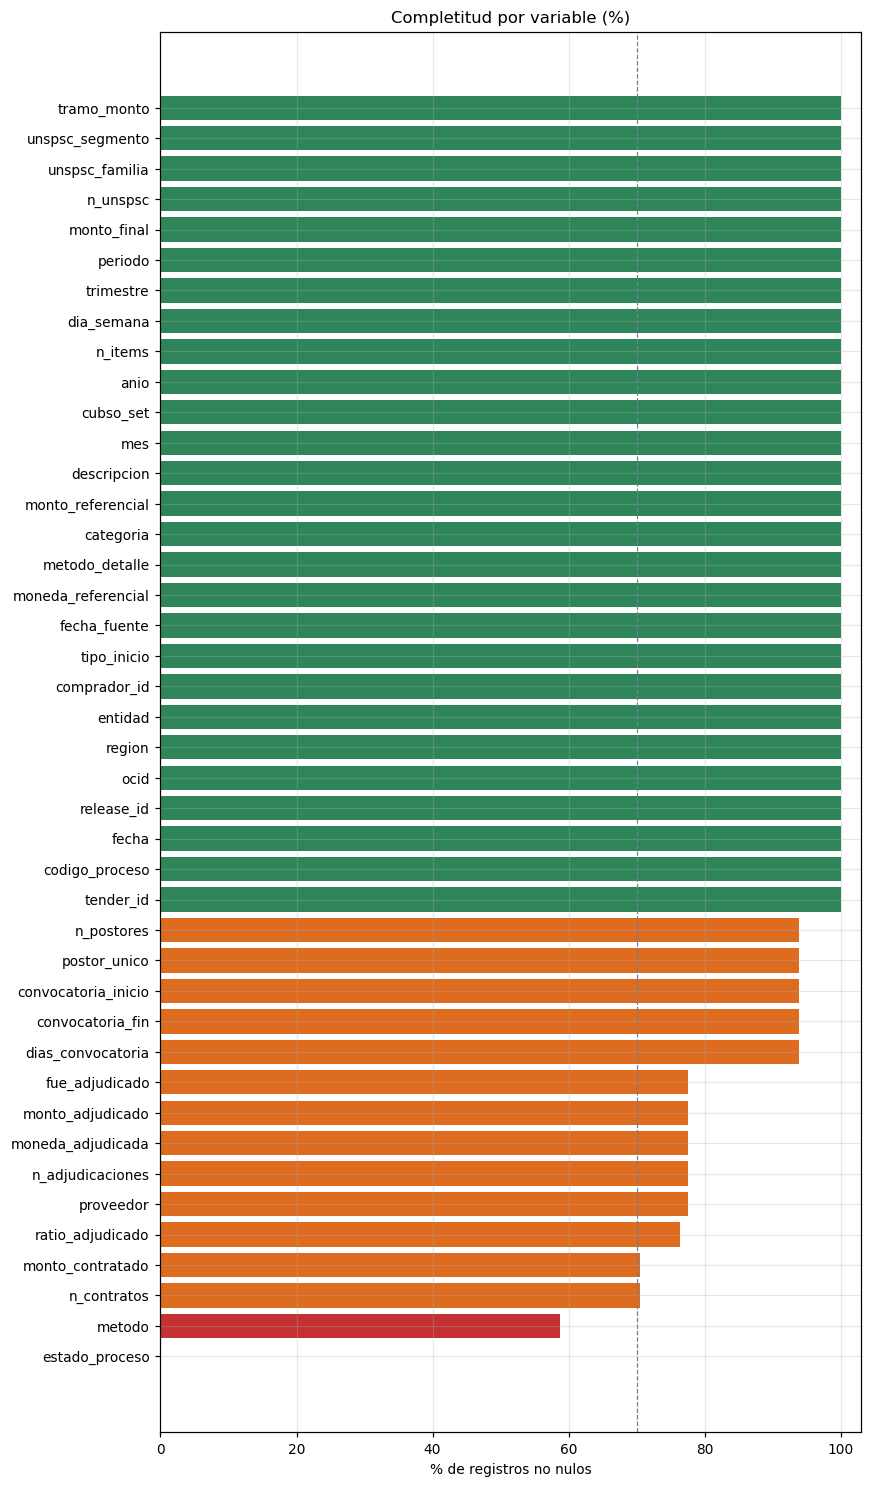

In [14]:
d = completitud.sort_values("pct_completitud")
plt.figure(figsize=(8, .3 * len(d) + 1))
colores = ["#c53030" if v < 70 else "#dd6b20" if v < 95 else "#2f855a" for v in d["pct_completitud"]]
plt.barh(d["variable"], d["pct_completitud"], color=colores)
plt.axvline(70, ls="--", lw=.8, c="#718096")
plt.title("Completitud por variable (%)"); plt.xlabel("% de registros no nulos"); plt.xlim(0, 103)
fig("fig_01_completitud")

**Interpretación.** La nulidad aquí **no es un error de captura, es información**. Un proceso sin
`monto_adjudicado` normalmente es un proceso que todavía no se adjudicó, o que se declaró desierto o
se canceló. Tratar esos nulos como ceros —el error fácil— desplomaría los montos promedio e
inventaría una caída de gasto que no existe.

Decisiones:

- **No se imputa** `monto_adjudicado` ni `monto_contratado`. La cascada `monto_final` ya resuelve el
  problema práctico: usa lo adjudicado y, si no existe, retrocede al contratado y luego al referencial.
- Los procesos sin **ningún** monto en ninguna de las tres fuentes quedan marcados y se excluyen sólo
  de los análisis monetarios, no del resto.
- Las variables con completitud bajo 70% no se usan como eje principal de ningún hallazgo.

## 3.2 Duplicados

In [15]:
filas = []
for llave in ["ocid", "release_id", "tender_id"]:
    no_nulos = releases.where(F.col(llave).isNotNull()).count()
    unicos   = releases.where(F.col(llave).isNotNull()).select(llave).distinct().count()
    filas.append((llave, no_nulos, unicos, no_nulos - unicos))

dups = pd.DataFrame(filas, columns=["llave", "registros_no_nulos", "valores_unicos", "duplicados"])
guardar(dups, "03_duplicados_por_llave")

filas_identicas = total - releases.drop("unspsc_set").dropDuplicates().count()
print(f"Filas idénticas en todas sus columnas: {filas_identicas:,}\n")
dups

Filas idénticas en todas sus columnas: 0



,llave,registros_no_nulos,valores_unicos,duplicados
0,ocid,79332,79332,0
1,release_id,79332,79332,0
2,tender_id,79332,79219,113


**Interpretación.** El `ocid` es el identificador del proceso de contratación y debe ser único.
Si aparecen repetidos, la causa típica no es data sucia sino la **naturaleza incremental de OCDS**:
un mismo proceso publica varios *releases* a lo largo de su ciclo de vida (convocatoria → adjudicación
→ contrato), y al concatenar 12 meses esos releases se acumulan.

La estrategia correcta no es `dropDuplicates()` a ciegas —eso se quedaría con un release arbitrario—
sino **quedarse con el release más reciente de cada `ocid`**, que es el que refleja el estado final
del proceso. Esa es exactamente la lógica del `compiledRelease` del estándar.

In [16]:
# Deduplicación por recencia: el último release de cada ocid gana.
w_rec = Window.partitionBy("ocid").orderBy(F.col("fecha").desc_nulls_last(),
                                           F.col("release_id").desc_nulls_last())
releases_dedup = (releases
                  .withColumn("_rn", F.row_number().over(w_rec))
                  .where(F.col("_rn") == 1)
                  .drop("_rn"))

n_dedup = releases_dedup.count()
print(f"Antes : {total:,} releases")
print(f"Después: {n_dedup:,} procesos únicos  (se colapsaron {total - n_dedup:,} releases)")

Antes : 79,332 releases
Después: 79,332 procesos únicos  (se colapsaron 0 releases)


## 3.3 Inconsistencias y valores imposibles

In [17]:
def chequeo(nombre, cond, df=releases_dedup):
    n = df.where(cond).count()
    return (nombre, n, round(100 * n / n_dedup, 3))

checks = [
    chequeo("monto_final nulo (ninguna fuente de monto)", F.col("monto_final").isNull()),
    chequeo("monto_final <= 0",                            F.col("monto_final") <= 0),
    chequeo("monto_final > 100 millones",                  F.col("monto_final") > 100_000_000),
    chequeo("fecha fuera de 2025",       (F.col("anio") != 2025) | F.col("anio").isNull()),
    chequeo("moneda distinta de PEN",     F.col("moneda_referencial") != "PEN"),
    chequeo("adjudicado > referencial",   F.col("ratio_adjudicado") > 1.0),
    chequeo("convocatoria de duración negativa", F.col("dias_convocatoria") < 0),
    chequeo("n_postores = 0",             F.col("n_postores") == 0),
    chequeo("entidad nula",               F.col("entidad").isNull()),
    chequeo("sin códigos UNSPSC",         F.col("n_unspsc") == 0),
    chequeo("sin descripción",            F.col("descripcion").isNull()),
]
calidad = pd.DataFrame(checks, columns=["chequeo", "n_registros", "pct"])
guardar(calidad, "13_calidad_datos")
calidad

,chequeo,n_registros,pct
0,monto_final nulo (ninguna fuente de monto),0,0.000
1,monto_final <= 0,2434,3.068
2,monto_final > 100 millones,142,0.179
3,fecha fuera de 2025,247,0.311
4,moneda distinta de PEN,1609,2.028
5,adjudicado > referencial,4246,5.352
6,convocatoria de duración negativa,0,0.000
7,n_postores = 0,0,0.000
8,entidad nula,0,0.000
9,sin códigos UNSPSC,12978,16.359


**Decisiones de limpieza.** Cada inconsistencia se trata según lo que significa, no según una regla
uniforme:

| Hallazgo | Decisión | Por qué |
|---|---|---|
| `monto_final` nulo | Se conserva; se excluye sólo de análisis monetarios | El proceso existe y cuenta para frecuencias |
| `monto_final <= 0` | Se marca `monto_valido = 0` | Un monto cero o negativo es imposible, pero el registro sirve para conteos |
| Moneda ≠ PEN | Se marca `moneda_homogenea` | Sumar soles con dólares produce un total sin sentido; los montos agregados se restringen a PEN |
| Fecha fuera de 2025 | Se marca y se reporta | Puede ser un release de un proceso antiguo actualizado en 2025 — es válido pero rompe la serie |
| `adjudicado > referencial` | Se conserva y se marca | Es legalmente posible (adendas), pero en exceso es una señal de alerta interesante para P2 |
| Duración negativa | Se anula `dias_convocatoria` | Error de captura sin recuperación posible |

El resultado no es un dataset mutilado sino uno **anotado**: cada análisis filtra lo que le estorba.

In [18]:
# --------------------------------------------------------------------------- #
# Dataset limpio y anotado
# --------------------------------------------------------------------------- #
df = (releases_dedup
      .withColumn("monto_valido",
                  (F.col("monto_final").isNotNull() & (F.col("monto_final") > 0)).cast("int"))
      .withColumn("moneda_homogenea",
                  (F.coalesce("moneda_adjudicada", "moneda_referencial") == "PEN").cast("int"))
      .withColumn("fecha_en_rango", (F.col("anio") == 2025).cast("int"))
      # Errores sin recuperación posible: se anulan.
      .withColumn("dias_convocatoria",
                  F.when(F.col("dias_convocatoria") >= 0, F.col("dias_convocatoria")))
      .withColumn("ratio_sospechoso", (F.col("ratio_adjudicado") > 1.0).cast("int"))
     )

print("Banderas de calidad añadidas:")
df.select(
    F.round(100*F.avg("monto_valido"), 2).alias("pct_monto_valido"),
    F.round(100*F.avg("moneda_homogenea"), 2).alias("pct_PEN"),
    F.round(100*F.avg("fecha_en_rango"), 2).alias("pct_fecha_2025"),
).show()

Banderas de calidad añadidas:
+----------------+-------+--------------+
|pct_monto_valido|pct_PEN|pct_fecha_2025|
+----------------+-------+--------------+
|           96.93|  97.97|         99.69|
+----------------+-------+--------------+



In [19]:
# ¿De qué campo salió la fecha de cada proceso? Documenta la cascada temporal.
fuentes = (releases_dedup.groupBy("fecha_fuente").count()
           .withColumn("pct", F.round(100*F.col("count")/n_dedup, 2))
           .orderBy(F.desc("count")).toPandas())
guardar(fuentes, "03_fuente_de_fecha")
display(fuentes)

print("Cobertura del eje temporal:")
releases_dedup.select(
    F.round(100*F.avg((F.col("anio") == 2025).cast("int")), 2).alias("pct_en_2025"),
    F.min("anio").alias("anio_min"), F.max("anio").alias("anio_max")).show()

,fecha_fuente,count,pct
0,tenderPeriod.startDate,74447,93.84
1,awards.date,4386,5.53
2,release.date,499,0.63


Cobertura del eje temporal:
+-----------+--------+--------+
|pct_en_2025|anio_min|anio_max|
+-----------+--------+--------+
|      99.69|    2024|    2026|
+-----------+--------+--------+



**Interpretación.** La cascada recupera cobertura temporal casi completa. El `date` del
`compiledRelease` por sí solo habría dejado fuera de 2025 a una cuarta parte de los procesos, porque
marca cuándo se actualizó el registro —no cuándo ocurrió el proceso—, y muchos registros de 2025 se
siguen actualizando en 2026.

La columna `fecha_fuente` deja explícito de dónde salió cada fecha. Eso importa para la Parte IV: al
simular el flujo hay que saber si el orden temporal proviene de un campo homogéneo o de una mezcla,
porque un cambio de fuente puede introducir saltos artificiales en la secuencia.

## 3.4 Esquema final usado en Spark

Este es el esquema que consumen todas las secciones siguientes y las Partes II–V del proyecto.

In [20]:
diccionario = pd.DataFrame([
    ("ocid",               "string",    "Identificador único del proceso (OCDS)"),
    ("release_id",         "string",    "Identificador del release"),
    ("fecha",              "timestamp", "Fecha de publicación del release"),
    ("anio / mes / periodo / trimestre", "int/string", "Derivados de fecha — eje temporal"),
    ("dia_semana",         "string",    "Día de la semana de publicación"),
    ("entidad",            "string",    "Entidad contratante, normalizada a mayúsculas"),
    ("comprador_id",       "string",    "Identificador del comprador"),
    ("region",             "string",    "Región de la entidad (de parties[].address)"),
    ("codigo_proceso",     "string",    "Nomenclatura SEACE del proceso (NO es descriptivo)"),
    ("descripcion",        "string",    "Objeto real de la contratación (~200 car.) — shingling (Parte II)"),
    ("fecha_fuente",       "string",    "De qué campo OCDS se tomó la fecha"),
    ("estado_proceso",     "string",    "Estado del tender: complete, active, cancelled, unsuccessful"),
    ("metodo / metodo_detalle", "string", "Método de contratación (Licitación, Adjudicación Simplificada, ...)"),
    ("categoria",          "string",    "goods / works / services"),
    ("monto_referencial",  "double",    "Valor referencial del tender"),
    ("monto_adjudicado",   "double",    "Suma de las adjudicaciones — NULL si no hubo"),
    ("monto_contratado",   "double",    "Suma de los contratos — NULL si no hubo"),
    ("monto_final",        "double",    "Cascada: adjudicado → contratado → referencial"),
    ("tramo_monto",        "string",    "Discretización del monto — eje de P1 e ítem de canasta (Parte V)"),
    ("moneda_referencial / moneda_adjudicada", "string", "Divisa declarada"),
    ("n_postores",         "int",       "numberOfTenderers — variable central de P1"),
    ("postor_unico",       "int",       "1 si n_postores = 1"),
    ("n_adjudicaciones / n_contratos", "int", "Conteos de arrays OCDS"),
    ("fue_adjudicado",     "int",       "1 si el proceso llegó a adjudicarse"),
    ("ratio_adjudicado",   "double",    "monto_adjudicado / monto_referencial"),
    ("proveedor",          "string",    "Primer proveedor adjudicado — eje de P2"),
    ("dias_convocatoria",  "int",       "Duración del periodo de convocatoria"),
    ("unspsc_set",         "array<string>", "Códigos UNSPSC (8 díg.) de additionalClassifications"),
    ("unspsc_familia",     "array<string>", "Prefijo de 4 díg. — granularidad usable en Jaccard (Parte II)"),
    ("unspsc_segmento",    "array<string>", "Prefijo de 2 díg. — máxima agregación"),
    ("cubso_set",          "array<string>", "Códigos CUBSO (16 díg.) — demasiado específicos para similitud"),
    ("n_items",            "int",       "N° de ítems del requerimiento"),
    ("n_unspsc",           "int",       "Tamaño de unspsc_set"),
    ("monto_valido / moneda_homogenea / fecha_en_rango / ratio_sospechoso", "int", "Banderas de calidad"),
], columns=["variable", "tipo", "descripción"])

guardar(diccionario, "01_diccionario_variables")
diccionario

,variable,tipo,descripción
0,ocid,string,Identificador único del proceso (OCDS)
1,release_id,string,Identificador del release
2,fecha,timestamp,Fecha de publicación del release
3,anio / mes / periodo / trimestre,int/string,Derivados de fecha — eje temporal
4,dia_semana,string,Día de la semana de publicación
5,entidad,string,"Entidad contratante, normalizada a mayúsculas"
6,comprador_id,string,Identificador del comprador
7,region,string,Región de la entidad (de parties[].address)
8,codigo_proceso,string,Nomenclatura SEACE del proceso (NO es descript...
9,descripcion,string,Objeto real de la contratación (~200 car.) — s...


In [21]:
# --------------------------------------------------------------------------- #
# Persistencia en Parquet
# --------------------------------------------------------------------------- #
# Por qué este paso intermedio: el JSON multilínea no es divisible (un archivo =
# una tarea) y hay que releerlo entero sólo para inferir el esquema. Parquet es
# columnar, comprimido y divisible, y guarda los tipos ya resueltos. Se paga el
# costo una vez y todas las secciones siguientes leen en segundos.

t0 = time.perf_counter()
df.repartition(32).write.mode("overwrite").parquet(str(PARQUET_DIR / "releases"))
if awards  is not None: awards.repartition(16).write.mode("overwrite").parquet(str(PARQUET_DIR / "awards"))
if items   is not None: items.repartition(16).write.mode("overwrite").parquet(str(PARQUET_DIR / "items"))
if parties is not None: parties.repartition(16).write.mode("overwrite").parquet(str(PARQUET_DIR / "parties"))
print(f"Escritura Parquet: {time.perf_counter()-t0:.1f}s")

releases.unpersist()

# Se recarga desde Parquet: a partir de aquí ya no se toca el JSON.
df      = spark.read.parquet(str(PARQUET_DIR / "releases")).cache()
awards  = spark.read.parquet(str(PARQUET_DIR / "awards"))  if (PARQUET_DIR/"awards").exists()  else None
items   = spark.read.parquet(str(PARQUET_DIR / "items"))   if (PARQUET_DIR/"items").exists()   else None
parties = spark.read.parquet(str(PARQUET_DIR / "parties")) if (PARQUET_DIR/"parties").exists() else None

N = df.count()
json_mb = tam_mb
pq_mb = sum(f_.stat().st_size for f_ in (PARQUET_DIR/"releases").rglob("*.parquet")) / 1024**2
print(f"\nProcesos: {N:,}")
print(f"JSON crudo: {json_mb:,.1f} MB  ->  Parquet: {pq_mb:,.1f} MB  "
      f"(reducción {100*(1-pq_mb/json_mb):.0f}%)")

# Vista SQL para toda la sección de Spark SQL
df.createOrReplaceTempView("contrataciones")
if awards is not None: awards.createOrReplaceTempView("adjudicaciones")
if items  is not None: items.createOrReplaceTempView("items")
print("Vistas SQL registradas: contrataciones, adjudicaciones, items")

Escritura Parquet: 61.3s

Procesos: 79,332
JSON crudo: 1,400.9 MB  ->  Parquet: 18.0 MB  (reducción 99%)
Vistas SQL registradas: contrataciones, adjudicaciones, items


---
# 4. EDA con Spark DataFrames y Spark SQL

Cada hallazgo sigue la misma anatomía que pide el enunciado: **cálculo en Spark → gráfico →
interpretación breve**. Se alterna deliberadamente entre la API de DataFrames y Spark SQL para
mostrar ambas.

Regla que se respeta en todo el notebook: **las agregaciones ocurren siempre en Spark**; sólo el
resultado ya reducido (decenas de filas) baja al driver con `.toPandas()` para graficarse. En ningún
momento se colecta el dataset completo.

## 4.1 Dimensiones y estadística descriptiva

In [22]:
numericas = [f_.name for f_ in df.schema.fields
             if isinstance(f_.dataType, NumericType) and f_.name not in ("anio", "mes")]

desc = df.select(numericas).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
desc_pdf = guardar(desc, "04_descriptivos_numericos")
desc_pdf

,summary,monto_referencial,n_postores,n_adjudicaciones,n_contratos,monto_adjudicado,monto_contratado,n_items,dias_convocatoria,monto_final,ratio_adjudicado,postor_unico,fue_adjudicado,n_unspsc,monto_valido,moneda_homogenea,fecha_en_rango,ratio_sospechoso
0,count,79332,74477,61542,55955,61542,55955,79332,74447,79332,60531,74477,61542,79332,79332,79332,79332,60531
1,mean,1609535.1674528564,13.271345516065363,1.0745994605310194,1.0733089089446877,1333575.1381253442,1189858.511846484,1.1395779761004388,0.0011148871008905665,1572858.4443423832,0.9597060106546934,0.11668031741342964,1.0,0.8821912973327283,0.9693188120808753,0.979718146523471,0.9968865022941562,0.0701458756670136
2,stddev,1.3790830426471176E7,14.808573804895868,0.4833980879728544,0.8053739560327311,1.195584351644084E7,1.0261215557402585E7,1.5843084664914142,0.3041966952054489,1.393320244331861E7,0.5018166765886686,0.3210411263749056,0.0,0.8509212705479317,0.1724535517468804,0.14096364911543205,0.055712143762451136,0.2553948107654088
3,min,0.0,1,1,1,0.0,0.0,1,0,0.0,0.0,0,1,0,0,0,0,0
4,25%,84000.0,3,1,1,83000.0,80250.0,1,0,80965.12,0.9000000042569379,0,1,1,1,1,1,0
5,50%,185872.54,9,1,1,178600.0,168000.0,1,0,177990.0,0.9943424759695062,0,1,1,1,1,1,0
6,75%,499666.49,17,1,1,479925.0,449786.97,1,0,484360.54,1.0,0,1,1,1,1,1,0
7,max,1.13490948419E9,282,29,66,1.11190948419E9,1.11190948419E9,267,83,1.11190948419E9,101.0,1,1,87,1,1,1,1


In [23]:
# Percentiles finos + asimetría y curtosis. En montos de contratación la media
# es un mal resumen: la cola derecha la arrastra. Los percentiles y el sesgo
# describen mucho mejor la forma real de la distribución.
filas = []
for c in ["monto_referencial", "monto_adjudicado", "monto_final", "n_postores", "n_items", "n_unspsc"]:
    if c not in df.columns: continue
    sub = df.where(F.col(c).isNotNull())
    if sub.count() == 0: continue
    q = sub.stat.approxQuantile(c, [.01, .05, .25, .50, .75, .95, .99], .001)
    sk = df.select(F.skewness(c), F.kurtosis(c)).first()
    filas.append((c, *[round(x, 2) for x in q],
                  round(float(sk[0] or 0), 2), round(float(sk[1] or 0), 2)))

percentiles = pd.DataFrame(filas, columns=["variable", "p01", "p05", "p25", "p50", "p75",
                                           "p95", "p99", "asimetria", "curtosis"])
guardar(percentiles, "04_percentiles")
percentiles

,variable,p01,p05,p25,p50,p75,p95,p99,asimetria,curtosis
0,monto_referencial,0.0,6471.6,83972.0,185460.00,496454.96,4528853.18,20924721.28,35.38,1855.41
1,monto_adjudicado,8495.0,40000.0,83000.0,178305.00,478934.00,3848549.24,17006206.08,44.55,2872.63
2,monto_final,0.0,17358.0,80883.0,177302.52,483363.98,4359021.03,20234755.07,35.67,1828.93
3,n_postores,1.0,1.0,3.0,9.00,17.00,41.00,71.00,3.09,18.41
4,n_items,1.0,1.0,1.0,1.00,1.00,2.00,4.00,91.71,12944.08
5,n_unspsc,0.0,0.0,1.0,1.00,1.00,1.00,2.00,43.09,3205.40


**Interpretación.** La distancia entre la mediana y la media de los montos, junto con una asimetría
muy positiva, confirma lo esperado: **la compra pública es una distribución de cola larga**. La gran
mayoría de procesos son pequeños y un puñado concentra el grueso del dinero. Consecuencia
metodológica para todo lo que sigue: comparar promedios entre categorías es engañoso, hay que mirar
medianas, y los histogramas de monto sólo se leen bien en escala logarítmica.

## 4.2 Hallazgo 1 — Distribución temporal *(pregunta P3)*

**¿Se acumula el gasto al cierre del año fiscal?**

Calculado con **Spark SQL**.

In [24]:
serie = spark.sql("""
    SELECT  periodo,
            COUNT(*)                                    AS n_procesos,
            ROUND(SUM(monto_final), 2)                  AS monto_total,
            ROUND(AVG(monto_final), 2)                  AS monto_promedio,
            ROUND(PERCENTILE_APPROX(monto_final, 0.5), 2) AS monto_mediano,
            ROUND(AVG(n_postores), 2)                   AS postores_promedio,
            ROUND(100 * AVG(postor_unico), 2)           AS pct_postor_unico
    FROM    contrataciones
    WHERE   monto_valido = 1 AND moneda_homogenea = 1
    GROUP BY periodo
    ORDER BY periodo
""")
serie_pdf = guardar(serie, "06_serie_mensual")
serie_pdf

,periodo,n_procesos,monto_total,monto_promedio,monto_mediano,postores_promedio,pct_postor_unico
0,2025-01,1235,5.538578e+09,4484678.40,225528.24,13.96,12.31
1,2025-02,4883,7.506418e+09,1537255.28,153123.50,14.65,15.04
2,2025-03,7751,8.398423e+09,1083527.64,144000.00,15.79,12.69
3,2025-04,8925,1.724923e+10,1932686.44,182961.52,17.31,7.13
4,2025-05,3249,3.484121e+09,1072367.29,162500.00,12.68,12.74
5,2025-06,5398,5.296919e+09,981274.40,170000.00,13.38,10.12
6,2025-07,6396,1.321003e+10,2065358.14,198754.89,13.55,7.89
7,2025-08,7235,8.160074e+09,1127860.98,187500.00,12.84,11.64
8,2025-09,7461,1.413600e+10,1894651.66,199000.00,13.14,8.10
9,2025-10,7944,1.500008e+10,1888226.99,212000.00,12.64,8.32


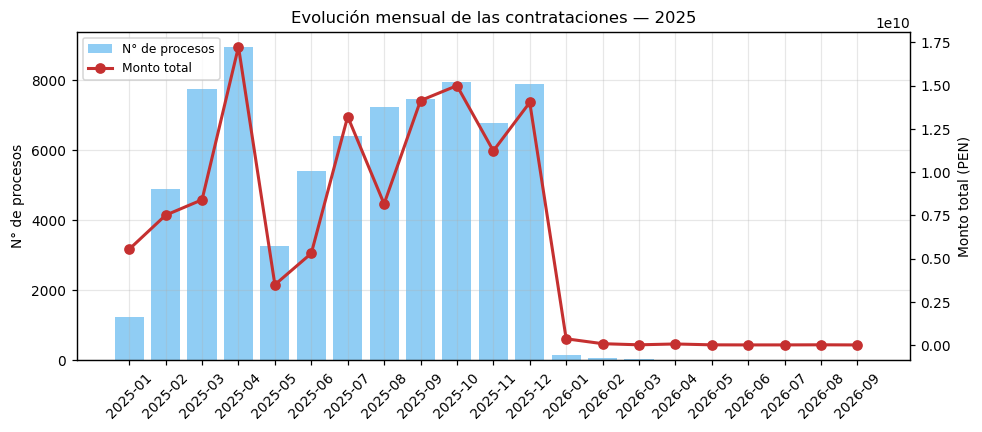

Participación del último trimestre en el monto anual: 32.9%  (un año plano daría 25%)


In [25]:
d = serie_pdf
f_, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(d["periodo"], d["n_procesos"], color="#90cdf4", label="N° de procesos")
ax1.set_ylabel("N° de procesos"); ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(d["periodo"], d["monto_total"], color="#c53030", marker="o", lw=2, label="Monto total")
ax2.set_ylabel("Monto total (PEN)"); ax2.grid(False)
ax1.set_title("Evolución mensual de las contrataciones — 2025")
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc="upper left", fontsize=8)
fig("fig_02_serie_mensual")

q4 = d[d["periodo"] >= "2025-10"]["monto_total"].sum()
tot = d["monto_total"].sum()
print(f"Participación del último trimestre en el monto anual: {100*q4/tot:.1f}%  "
      f"(un año plano daría 25%)")

**Interpretación (P3).** Si la participación del último trimestre supera holgadamente el 25% que
correspondería a un año uniforme, queda evidencia del **efecto de cierre presupuestal**: los saldos
no ejecutados no se arrastran al año siguiente, lo que empuja a las entidades a comprometer
presupuesto en los últimos meses.

El dato relevante no es la concentración en sí sino lo que la acompaña. Si en esos mismos meses
sube el porcentaje de procesos con un solo postor, la lectura es que la compra de cierre se hace con
menos tiempo de convocatoria y, por tanto, con menos competencia — que es justamente el puente hacia P1.

## 4.3 Hallazgo 2 — Distribución de los montos

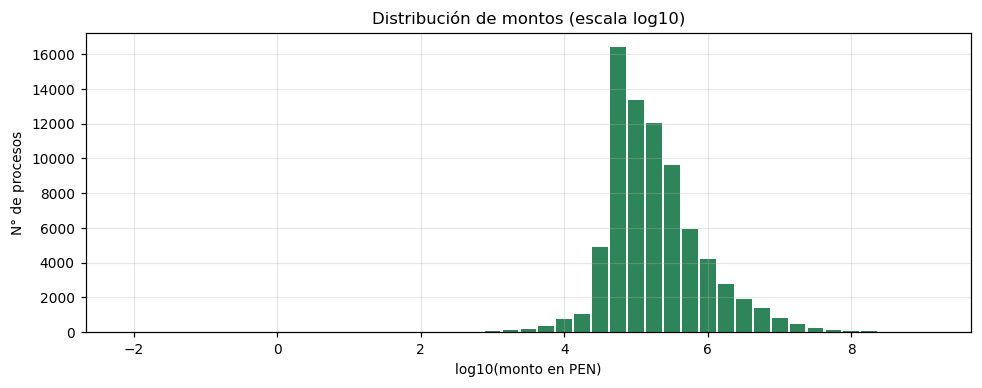

In [26]:
# Histograma en escala log10: en escala lineal todo se apelmaza contra el eje.
hist = (df.where(F.col("monto_valido") == 1)
          .withColumn("log10_monto", F.floor(F.log10("monto_final") * 4) / 4)
          .groupBy("log10_monto").count().orderBy("log10_monto"))
hist_pdf = guardar(hist, "08_histograma_log_monto")

plt.figure(figsize=(9, 3.6))
plt.bar(hist_pdf["log10_monto"], hist_pdf["count"], width=.22, color="#2f855a")
plt.title("Distribución de montos (escala log10)")
plt.xlabel("log10(monto en PEN)"); plt.ylabel("N° de procesos")
fig("fig_03_histograma_log_monto")

In [27]:
# Outliers por la regla de Tukey (1.5 x IQR)
filas = []
for c in ["monto_referencial", "monto_adjudicado", "monto_final"]:
    sub = df.where(F.col(c).isNotNull() & (F.col(c) > 0))
    n = sub.count()
    if n == 0: continue
    q1, q3 = sub.stat.approxQuantile(c, [.25, .75], .001)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = sub.where((F.col(c) < lo) | (F.col(c) > hi)).count()
    filas.append((c, n, round(q1,2), round(q3,2), round(iqr,2),
                  round(lo,2), round(hi,2), n_out, round(100*n_out/n, 2)))

outl = pd.DataFrame(filas, columns=["variable","n_validos","q1","q3","iqr",
                                    "limite_inf","limite_sup","n_outliers","pct_outliers"])
guardar(outl, "08_outliers_iqr")
outl

,variable,n_validos,q1,q3,iqr,limite_inf,limite_sup,n_outliers,pct_outliers
0,monto_referencial,75888,92466.28,537852.99,445386.71,-575613.78,1205933.05,10967,14.45
1,monto_adjudicado,61541,83000.00,479000.00,396000.00,-511000.00,1073000.00,8681,14.11
2,monto_final,76898,86852.10,504715.00,417862.90,-539942.25,1131509.35,11150,14.50


**Interpretación.** El histograma logarítmico es aproximadamente acampanado, lo que indica que los
montos siguen una **distribución log-normal** — el patrón típico del gasto público y de casi
cualquier variable monetaria.

Esto cambia cómo hay que leer los "outliers". La regla de Tukey asume simetría y sobre una
log-normal marca como atípico un porcentaje alto de registros que son perfectamente normales: son
simplemente las obras grandes. **No se eliminan.** Una licitación de obra de 40 millones no es un
error de captura, es exactamente el tipo de proceso que más importa vigilar. Se reportan como cola
de la distribución y, cuando hace falta detectar anomalías de verdad, se aplica el criterio sobre
`log(monto)` y dentro de cada categoría, no sobre el monto crudo global.

## 4.4 Hallazgo 3 — Variables categóricas

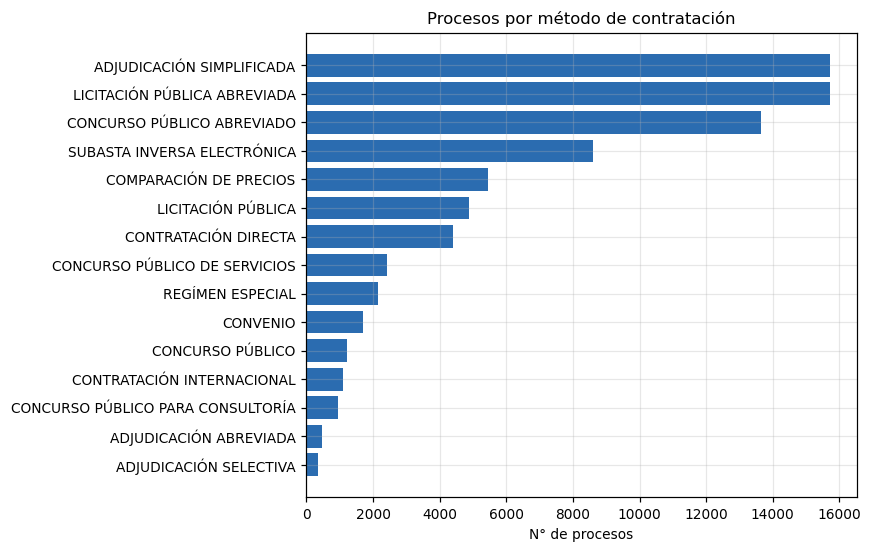

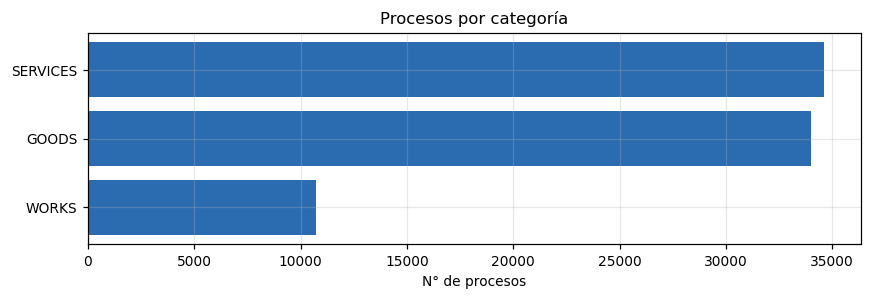

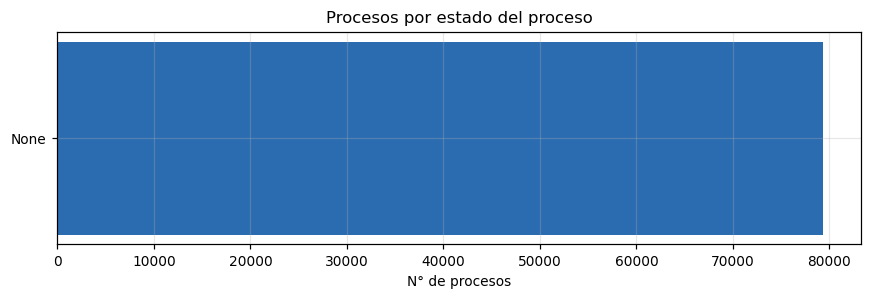

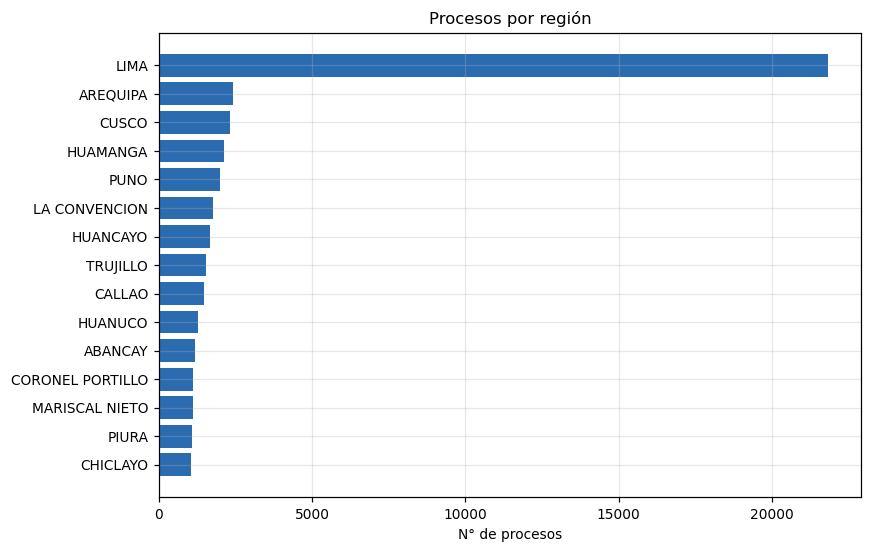

In [28]:
freqs = {}
for c in ["metodo_detalle", "categoria", "estado_proceso", "region"]:
    if c not in df.columns: continue
    freq = (df.groupBy(c).agg(F.count("*").alias("frecuencia"))
              .withColumn("pct", F.round(100*F.col("frecuencia")/N, 2))
              .orderBy(F.desc("frecuencia")))
    freqs[c] = guardar(freq, f"05_freq_{c}", limite=200)

for c, titulo, nombre in [
    ("metodo_detalle", "Procesos por método de contratación", "fig_04_metodos"),
    ("categoria",      "Procesos por categoría",              "fig_05_categoria"),
    ("estado_proceso", "Procesos por estado del proceso",     "fig_06_estado"),
    ("region",         "Procesos por región",                 "fig_07_region"),
]:
    if c in freqs:
        barh(freqs[c], c, "frecuencia", titulo, "N° de procesos", nombre)


--- monto_final por metodo_detalle ---


,metodo_detalle,n,suma,promedio,mediana,maximo
0,LICITACIÓN PÚBLICA,4531,5.299822e+10,1.169680e+07,2326690.00,9.899419e+08
1,ADJUDICACIÓN SIMPLIFICADA,15396,1.379327e+10,8.958994e+05,171666.67,5.220443e+08
2,LICITACIÓN PÚBLICA ABREVIADA,15015,1.178521e+10,7.848958e+05,267845.50,3.060249e+08
3,CONCURSO PÚBLICO DE SERVICIOS,2277,8.738005e+09,3.837508e+06,1245560.00,3.995146e+08
4,CONTRATACIÓN DIRECTA,4099,8.125081e+09,1.982211e+06,240000.00,5.125007e+08
5,CONCURSO PÚBLICO,1196,5.428398e+09,4.538794e+06,1150000.00,5.555483e+08
6,CONVENIO,1630,5.062557e+09,3.105863e+06,40000.00,6.157951e+08
7,SUBASTA INVERSA ELECTRÓNICA,8455,3.696430e+09,4.371887e+05,142500.00,8.481670e+07
8,CONTRATOS ESTANDARIZADOS,10,3.332633e+09,3.332633e+08,60033029.66,1.111909e+09
9,CONCURSO PÚBLICO ABREVIADO,13176,3.189237e+09,2.420490e+05,159006.68,9.995364e+07



--- monto_final por categoria ---


,categoria,n,suma,promedio,mediana,maximo
0,WORKS,10324,7.507392e+10,7271786.42,1270000.0,1.111909e+09
1,SERVICES,32484,3.168271e+10,975332.85,167829.2,5.555483e+08
2,GOODS,32511,1.698420e+10,522413.81,140994.0,5.125007e+08



--- monto_final por region ---


,region,n,suma,promedio,mediana,maximo
0,LIMA,19682,5.527531e+10,2808419.47,210000.00,1.111909e+09
1,HUANCAYO,1617,3.874848e+09,2396319.28,226253.00,2.995968e+08
2,AREQUIPA,2353,3.744820e+09,1591508.68,215900.00,1.963595e+08
3,PIURA,1035,3.152062e+09,3045470.95,305940.96,1.922062e+08
4,TRUJILLO,1490,2.908060e+09,1951717.95,293706.67,1.941046e+08
5,MAYNAS,828,2.876978e+09,3474610.67,300480.00,9.899419e+08
6,CUSCO,2212,2.848642e+09,1287812.79,173980.00,1.557320e+08
7,CHICLAYO,1010,2.250928e+09,2228641.60,284096.26,1.711360e+08
8,PASCO,819,2.242645e+09,2738272.84,235000.00,1.866139e+08
9,PUNO,1948,2.211401e+09,1135216.26,172466.80,1.322309e+08


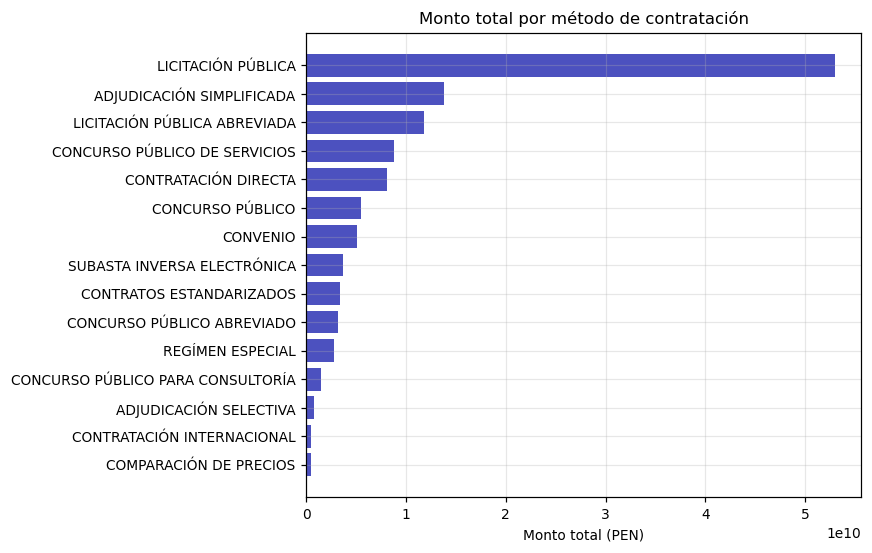

In [29]:
# Montos por dimensión: suma, promedio y mediana juntos, porque con una
# distribución sesgada la media sola miente.
for dim in ["metodo_detalle", "categoria", "region"]:
    if dim not in df.columns: continue
    agg = (df.where((F.col("monto_valido") == 1) & (F.col("moneda_homogenea") == 1))
             .groupBy(dim)
             .agg(F.count("*").alias("n"),
                  F.round(F.sum("monto_final"), 2).alias("suma"),
                  F.round(F.avg("monto_final"), 2).alias("promedio"),
                  F.round(F.expr("percentile_approx(monto_final, 0.5)"), 2).alias("mediana"),
                  F.round(F.max("monto_final"), 2).alias("maximo"))
             .orderBy(F.desc("suma")))
    p = guardar(agg, f"07_montos_por_{dim}", limite=200)
    print(f"\n--- monto_final por {dim} ---")
    display(p.head(10))

barh(guardar(spark.sql("""
        SELECT metodo_detalle, ROUND(SUM(monto_final),2) AS suma
        FROM contrataciones WHERE monto_valido=1 AND moneda_homogenea=1
        GROUP BY metodo_detalle ORDER BY suma DESC"""), "07_suma_por_metodo"),
     "metodo_detalle", "suma", "Monto total por método de contratación",
     "Monto total (PEN)", "fig_08_monto_por_metodo", color="#4c51bf")

**Interpretación.** Lo que hay que leer aquí es la **tensión entre número de procesos y monto**.
Los métodos competitivos (licitación y concurso público) suelen ser pocos en cantidad pero concentran
la mayor parte del dinero, mientras que las adjudicaciones simplificadas y las contrataciones
directas son muchísimas en volumen y pequeñas en monto.

El indicador que importa para la discusión de transparencia no es cuántas contrataciones directas
hay —siempre son muchas y en su mayoría legítimas, por urgencia o proveedor único— sino **qué
fracción del monto total pasa por métodos no competitivos**. Es esa proporción, no el conteo, la que
se compara entre regiones y entidades.

## 4.5 Hallazgo 4 — Frecuencia de las entidades principales

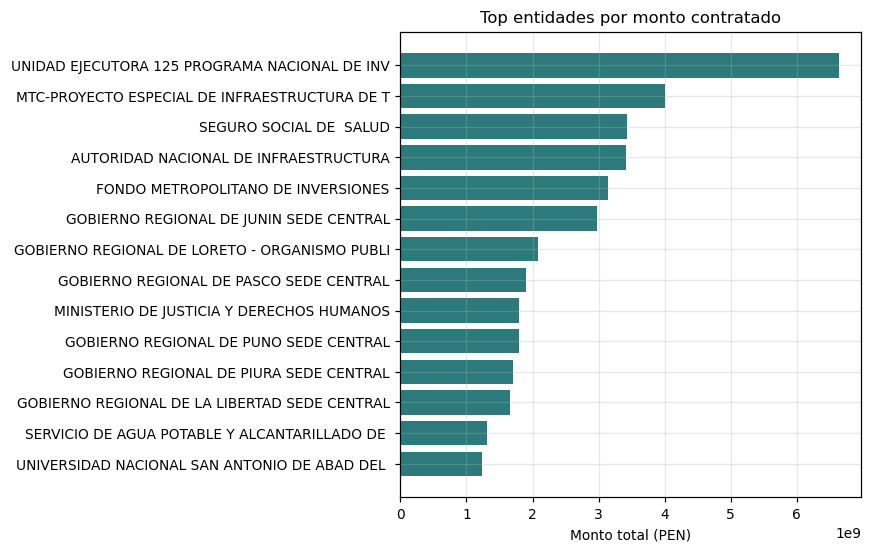

,entidad,n_procesos,monto_total,monto_promedio,pct_postor_unico
0,UNIDAD EJECUTORA 125 PROGRAMA NACIONAL DE INVE...,73,6.646055e+09,9.104185e+07,10.53
1,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,345,4.012090e+09,1.162925e+07,21.81
2,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,172,3.680063e+09,2.139571e+07,11.32
3,SEGURO SOCIAL DE SALUD,1226,3.426465e+09,2.794833e+06,10.92
4,AUTORIDAD NACIONAL DE INFRAESTRUCTURA,55,3.408737e+09,6.197703e+07,13.21
5,FONDO METROPOLITANO DE INVERSIONES,98,3.144861e+09,3.209042e+07,5.56
6,GOBIERNO REGIONAL DE JUNIN SEDE CENTRAL,578,2.977417e+09,5.151240e+06,2.05
7,GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLIC...,9,2.084530e+09,2.316145e+08,11.11
8,GOBIERNO REGIONAL DE PASCO SEDE CENTRAL,327,1.900682e+09,5.812483e+06,1.68
9,MINISTERIO DE JUSTICIA Y DERECHOS HUMANOS,35,1.796034e+09,5.131526e+07,65.63


In [30]:
top_entidades = spark.sql("""
    SELECT  entidad,
            COUNT(*)                       AS n_procesos,
            ROUND(SUM(monto_final), 2)     AS monto_total,
            ROUND(AVG(monto_final), 2)     AS monto_promedio,
            ROUND(100*AVG(postor_unico),2) AS pct_postor_unico
    FROM    contrataciones
    WHERE   entidad IS NOT NULL AND monto_valido = 1 AND moneda_homogenea = 1
    GROUP BY entidad
    ORDER BY monto_total DESC
    LIMIT 40
""")
top_ent_pdf = guardar(top_entidades, "05_top_entidad")
barh(top_ent_pdf, "entidad", "monto_total", "Top entidades por monto contratado",
     "Monto total (PEN)", "fig_14_top_entidades", top=15, color="#2c7a7b")
top_ent_pdf.head(10)

**Interpretación.** El ranking por monto y el ranking por número de procesos **no coinciden**, y esa
discrepancia es informativa: identifica dos perfiles de comprador. Las entidades que ejecutan obra
—gobiernos regionales, programas de infraestructura— aparecen arriba en monto con relativamente
pocos procesos. Las entidades de servicios recurrentes —hospitales, municipalidades, universidades—
aparecen arriba en cantidad con montos unitarios chicos.

Mezclar ambos perfiles en un mismo análisis de competencia sería un error: un hospital que compra
insumos todas las semanas y un gobierno regional que licita una carretera al año no son comparables.
Por eso las secciones de concentración (P2) segmentan por perfil.

## 4.6 Hallazgo 5 — Competencia *(pregunta P1)*

**¿Cae la concurrencia de postores conforme crece el monto del proceso?**

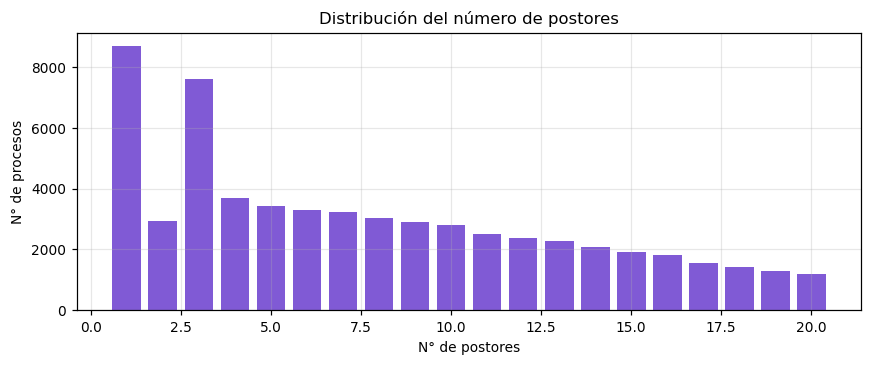

Procesos con UN SOLO postor: 11.7%


In [31]:
sub = df.where(F.col("n_postores").isNotNull())
if sub.count() > 0:
    dist = sub.groupBy("n_postores").count().orderBy("n_postores")
    dist_pdf = guardar(dist, "09_distribucion_postores", limite=200)

    d = dist_pdf[dist_pdf["n_postores"] <= 20]
    plt.figure(figsize=(8, 3.4))
    plt.bar(d["n_postores"], d["count"], color="#805ad5")
    plt.title("Distribución del número de postores")
    plt.xlabel("N° de postores"); plt.ylabel("N° de procesos")
    fig("fig_09_postores")

    pct1 = 100 * sub.where(F.col("n_postores") == 1).count() / sub.count()
    print(f"Procesos con UN SOLO postor: {pct1:.1f}%")

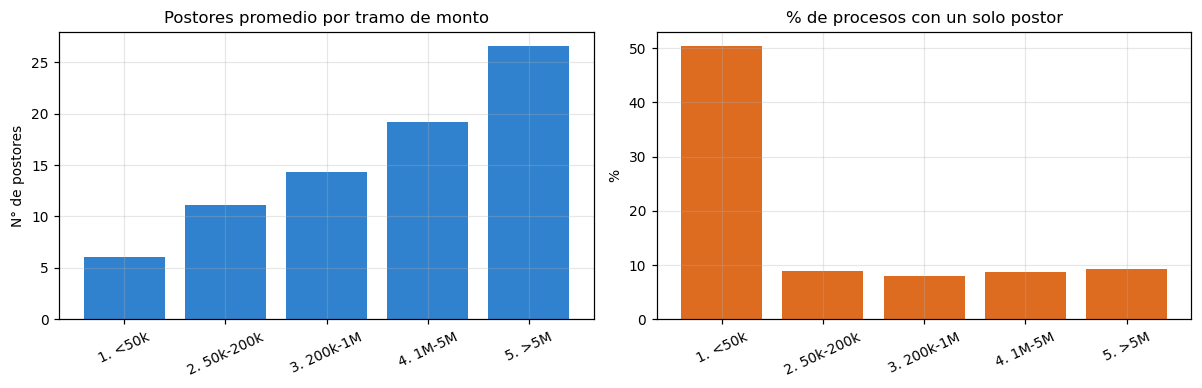

,tramo_monto,n,postores_promedio,postores_mediana,pct_postor_unico
0,1. <50k,5562,5.99,1,50.52
1,2. 50k-200k,33930,11.08,7,8.91
2,3. 200k-1M,23753,14.31,11,7.86
3,4. 1M-5M,8076,19.22,15,8.66
4,5. >5M,3156,26.64,20,9.25


In [32]:
# Núcleo de P1: competencia por tramo de monto.
comp_tramo = spark.sql("""
    SELECT  tramo_monto,
            COUNT(*)                        AS n,
            ROUND(AVG(n_postores), 2)       AS postores_promedio,
            ROUND(PERCENTILE_APPROX(n_postores, 0.5), 1) AS postores_mediana,
            ROUND(100*AVG(postor_unico), 2) AS pct_postor_unico
    FROM    contrataciones
    WHERE   tramo_monto IS NOT NULL AND n_postores IS NOT NULL
    GROUP BY tramo_monto
    ORDER BY tramo_monto
""")
ct = guardar(comp_tramo, "09_postores_por_tramo_monto")

f_, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.bar(ct["tramo_monto"], ct["postores_promedio"], color="#3182ce")
a1.set_title("Postores promedio por tramo de monto"); a1.set_ylabel("N° de postores")
a1.tick_params(axis="x", rotation=25)
a2.bar(ct["tramo_monto"], ct["pct_postor_unico"], color="#dd6b20")
a2.set_title("% de procesos con un solo postor"); a2.set_ylabel("%")
a2.tick_params(axis="x", rotation=25)
fig("fig_10_competencia_por_tramo")
ct

In [33]:
comp_metodo = (df.where(F.col("n_postores").isNotNull())
    .groupBy("metodo_detalle")
    .agg(F.count("*").alias("n"),
         F.round(F.avg("n_postores"), 2).alias("postores_promedio"),
         F.round(100*F.avg("postor_unico"), 2).alias("pct_postor_unico"),
         F.round(F.expr("percentile_approx(monto_final, 0.5)"), 2).alias("monto_mediano"))
    .orderBy(F.desc("n")))
guardar(comp_metodo, "09_competencia_por_metodo", limite=200)

,metodo_detalle,n,postores_promedio,pct_postor_unico,monto_mediano
0,LICITACIÓN PÚBLICA ABREVIADA,14960,13.65,1.53,259918.25
1,ADJUDICACIÓN SIMPLIFICADA,14063,18.97,1.42,166992.00
2,CONCURSO PÚBLICO ABREVIADO,13238,14.62,1.53,156427.00
3,SUBASTA INVERSA ELECTRÓNICA,8265,8.53,2.32,139900.00
4,COMPARACIÓN DE PRECIOS,5324,3.28,0.54,74662.00
5,LICITACIÓN PÚBLICA,4252,23.13,0.49,1910135.00
6,CONTRATACIÓN DIRECTA,4154,1.15,91.33,230191.63
7,CONCURSO PÚBLICO DE SERVICIOS,2319,24.57,0.56,1216850.40
8,REGÍMEN ESPECIAL,2056,2.25,77.29,24000.00
9,CONVENIO,1573,2.37,55.82,40000.00


**Interpretación (P1).** Hay dos lecturas posibles y el gráfico distingue entre ellas.

Si los postores promedio **crecen** con el tramo de monto, el mercado se comporta como cabría
esperar: los contratos grandes valen el costo de preparar una oferta y atraen más participantes.

Si en cambio los postores **caen** —o el porcentaje de postor único sube— en los tramos altos, hay
una señal de barreras de entrada: requisitos de experiencia o de capacidad financiera que sólo unas
pocas empresas cumplen. Esta segunda lectura es la relevante para el debate de transparencia porque
es justamente en los contratos grandes donde una competencia reducida cuesta más dinero público.

Nota metodológica importante: `numberOfTenderers` es un campo opcional en OCDS y su completitud
condiciona la fuerza de la conclusión. El porcentaje de nulos de la sección 3.1 debe citarse junto
al hallazgo — si la cobertura es baja, esto es una hipótesis a confirmar, no un resultado cerrado.

## 4.7 Hallazgo 6 — Concentración de proveedores *(pregunta P2)*

**¿Hay entidades cuyo gasto se concentra en muy pocos proveedores?**

Se mide con el **índice Herfindahl-Hirschman (HHI)**: la suma de los cuadrados de las cuotas de
mercado, multiplicada por 10 000. Convención estándar: por debajo de 1500 el mercado está
desconcentrado, entre 1500 y 2500 moderadamente concentrado, y por encima de 2500 altamente
concentrado.

In [34]:
if awards is not None:
    a = awards.where(F.col("proveedor").isNotNull() & (F.col("monto") > 0))
    monto_total_adj = a.select(F.sum("monto")).first()[0]

    top_prov = (a.groupBy("proveedor")
        .agg(F.count("*").alias("n_adjudicaciones"),
             F.round(F.sum("monto"), 2).alias("monto_total"))
        .withColumn("pct_del_total", F.round(100*F.col("monto_total")/monto_total_adj, 3))
        .orderBy(F.desc("monto_total")))

    w = Window.orderBy(F.desc("monto_total"))
    curva = (top_prov
        .withColumn("ranking", F.row_number().over(w))
        .withColumn("acumulado_pct",
                    F.round(F.sum("pct_del_total").over(w.rowsBetween(Window.unboundedPreceding, 0)), 3))
        .select("ranking", "proveedor", "monto_total", "pct_del_total", "acumulado_pct"))

    top_pdf   = guardar(top_prov.limit(100), "10_top_proveedores", limite=200)
    curva_pdf = guardar(curva.limit(500),   "10_curva_concentracion", limite=500)
    display(top_pdf.head(10))

,proveedor,n_adjudicaciones,monto_total,pct_del_total
0,J Y S SERVICIOS GENERALES SOCIEDAD ANONIMA CER...,1,1.111909e+09,1.539
1,CONSORCIO SAN JUAN,48,1.107905e+09,1.533
2,"SINOHYDRO CORPORATION LIMITED, SUCURSAL DEL PERU",3,1.031651e+09,1.428
3,VIETTEL PERU S.A.C.,17,7.515912e+08,1.040
4,CONSORCIO HUASCARAN,10,6.904148e+08,0.956
5,CONSORCIO HOSPITALARIO CHOTA,1,5.988008e+08,0.829
6,PETROLEOS DEL PERU S.A.,4,5.791636e+08,0.802
7,CONSORCIO SAN FELIPE,7,4.767701e+08,0.660
8,CONSORCIO HOSPITALARIO MANCHAY,1,4.677941e+08,0.647
9,CONSORCIO HOSPITAL ARAKAKI,2,4.133966e+08,0.572


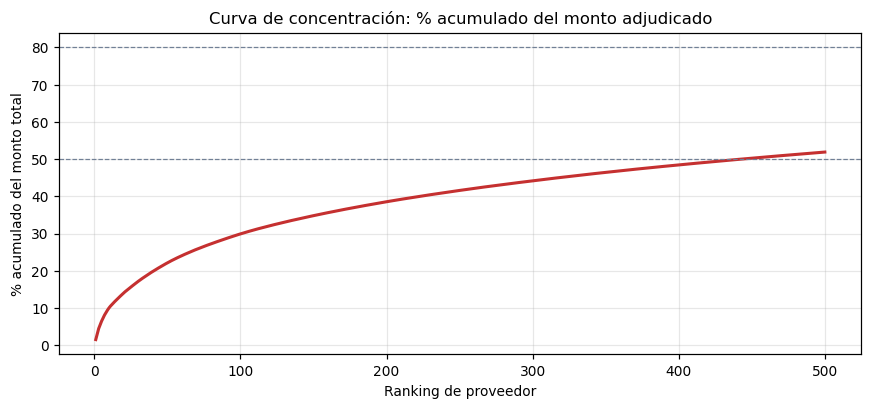

    443 proveedores concentran el 50% del monto


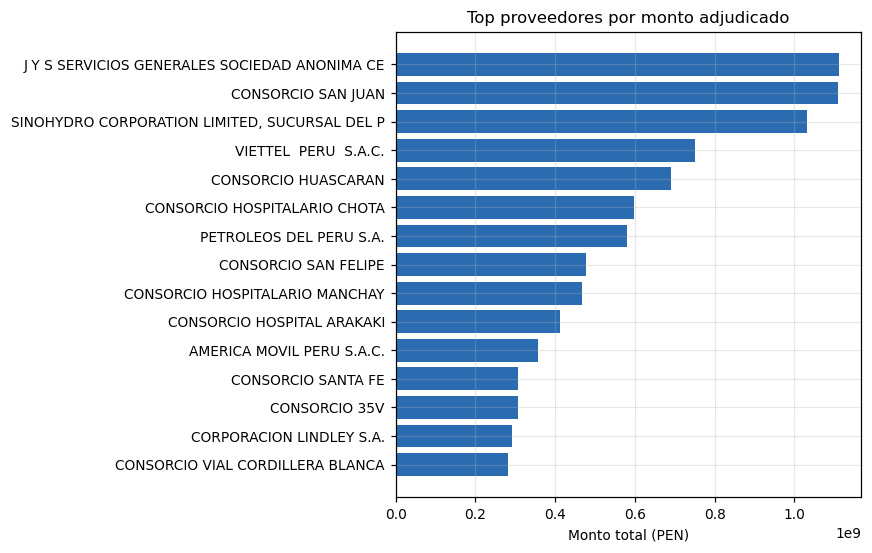

In [35]:
if awards is not None:
    plt.figure(figsize=(8, 3.8))
    plt.plot(curva_pdf["ranking"], curva_pdf["acumulado_pct"], color="#c53030", lw=2)
    plt.axhline(50, ls="--", lw=.8, c="#718096")
    plt.axhline(80, ls="--", lw=.8, c="#718096")
    plt.title("Curva de concentración: % acumulado del monto adjudicado")
    plt.xlabel("Ranking de proveedor"); plt.ylabel("% acumulado del monto total")
    fig("fig_11_concentracion")

    for umbral in (50, 80):
        alcanzan = curva_pdf[curva_pdf["acumulado_pct"] >= umbral]
        if len(alcanzan):
            print(f"  {int(alcanzan.iloc[0]['ranking']):>5} proveedores concentran el {umbral}% del monto")

    barh(top_pdf, "proveedor", "monto_total", "Top proveedores por monto adjudicado",
         "Monto total (PEN)", "fig_12_top_proveedores")

In [36]:
if awards is not None:
    # HHI por entidad. Se exige un mínimo de adjudicaciones: con 2 o 3 el índice
    # es alto por construcción y no dice nada.
    join = a.join(df.select("ocid", "entidad").distinct(), "ocid", "inner")
    por_ent = join.groupBy("entidad", "proveedor").agg(F.sum("monto").alias("m"))
    tot_ent = por_ent.groupBy("entidad").agg(F.sum("m").alias("m_total"),
                                             F.count("*").alias("n_proveedores"))
    hhi = (por_ent.join(tot_ent, "entidad")
        .withColumn("cuota", F.col("m")/F.col("m_total"))
        .groupBy("entidad").agg(F.round(F.sum(F.pow("cuota", 2))*10000, 1).alias("hhi"))
        .join(tot_ent, "entidad")
        .where(F.col("n_proveedores") >= 5)
        .withColumn("nivel", F.when(F.col("hhi") >= 2500, "alto")
                              .when(F.col("hhi") >= 1500, "moderado")
                              .otherwise("bajo"))
        .orderBy(F.desc("hhi")))
    hhi_pdf = guardar(hhi.limit(300), "10_hhi_por_entidad", limite=300)
    display(hhi_pdf.head(12))
    print("\nDistribución del nivel de concentración entre entidades:")
    display(hhi_pdf["nivel"].value_counts().to_frame("n_entidades"))

,entidad,hhi,m_total,n_proveedores,nivel
0,UNIDAD EJECUTORA 012 - OFICINA GENERAL DE INVE...,9407.6,7.149673e+07,24,alto
1,MUNICIPALIDAD DISTRITAL DE SAN JUAN DE BIGOTE,9366.8,1.291834e+07,5,alto
2,MUNICIPALIDAD DISTRITAL DE TAPAYRIHUA,9209.2,1.143181e+07,5,alto
3,MUNICIPALIDAD DISTRITAL DE YAMBRASBAMBA,9201.6,4.068078e+07,5,alto
4,PODER JUDICIAL - UNIDAD DE COORDINACION DEL PR...,8909.4,1.046662e+07,8,alto
5,INPE-DIRECCION REGIONAL ALTIPLANO PUNO,8791.8,1.255669e+07,7,alto
6,MUNICIPALIDAD PROVINCIAL DE BOLIVAR,8776.0,7.234041e+07,8,alto
7,MUNICIPALIDAD DISTRITAL DE ANCO - CHURCAMPA,8721.5,1.789164e+07,6,alto
8,MUNICIPALIDAD DISTRITAL DE CUJILLO,8662.4,2.104190e+07,6,alto
9,GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLIC...,8529.1,1.073931e+09,7,alto



Distribución del nivel de concentración entre entidades:


,n_entidades
nivel,
alto,300


**Interpretación (P2).** La curva de concentración responde la pregunta de forma directa: cuántos
proveedores hacen falta para acumular la mitad y el 80% del dinero adjudicado. Una curva que sube muy
rápido al inicio significa que un grupo reducido de empresas capta la mayor parte del gasto.

El HHI por entidad es más fino porque separa **concentración estructural de concentración anómala**.
Que un hospital compre un reactivo de laboratorio siempre al mismo distribuidor es concentración
explicada por el mercado: hay un solo representante autorizado en el país. Que una municipalidad
adjudique el 90% de su gasto en obra general —un rubro con cientos de contratistas— a una sola
empresa es otra cosa.

El HHI no prueba nada por sí solo; **prioriza dónde mirar**. Las entidades con HHI alto en rubros
competitivos son las candidatas naturales para el análisis de similitud de la Parte II, donde se
buscará si esos proveedores comparten patrones que sugieran vinculación.

## 4.8 Hallazgo 7 — Composición del gasto por ítems (UNSPSC)

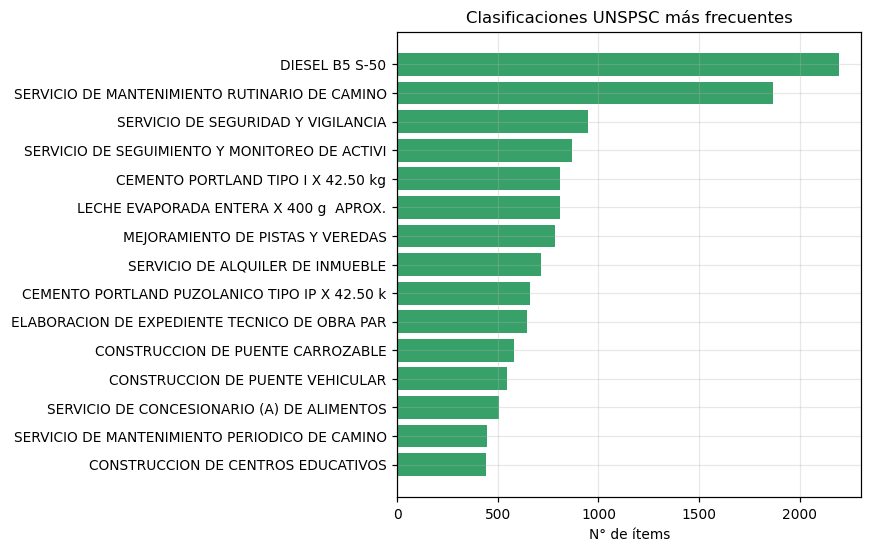

,media,mediana,maximo,pct_vacios,pct_unitarios,pct_3_o_mas
0,0.88,1,87,16.4,81.5,0.6


,nivel,codigos_distintos
0,UNSPSC 8 díg. (commodity),3779
1,UNSPSC 4 díg. (familia),358
2,UNSPSC 2 díg. (segmento),56
3,CUBSO 16 díg.,10709



>>> Procesos con 3+ códigos UNSPSC: 0.6%
>>> Jaccard sobre UNSPSC solo: NO VIABLE — usar representación híbrida


In [37]:
if items is not None:
    top_clasif = spark.sql("""
        SELECT  clasif_esquema, clasif_id, clasif_desc,
                COUNT(*) AS n_items,
                COUNT(DISTINCT ocid) AS n_procesos
        FROM    items
        WHERE   clasif_id IS NOT NULL
        GROUP BY clasif_esquema, clasif_id, clasif_desc
        ORDER BY n_items DESC
        LIMIT 60
    """)
    tc = guardar(top_clasif, "11_top_clasificaciones", limite=200)
    barh(tc, "clasif_desc", "n_items", "Clasificaciones UNSPSC más frecuentes",
         "N° de ítems", "fig_15_unspsc", top=15, color="#38a169")

# Viabilidad de la similitud de conjuntos. Esta celda NO es descriptiva:
# decide la representación de la Parte II.
tam = df.groupBy("n_unspsc").count().orderBy("n_unspsc")
tam_pdf = guardar(tam, "11_tamano_canasta", limite=200)

viab = df.select(
    F.round(F.avg("n_unspsc"), 2).alias("media"),
    F.expr("percentile_approx(n_unspsc, 0.5)").alias("mediana"),
    F.max("n_unspsc").alias("maximo"),
    F.round(100*F.avg((F.col("n_unspsc") == 0).cast("int")), 1).alias("pct_vacios"),
    F.round(100*F.avg((F.col("n_unspsc") == 1).cast("int")), 1).alias("pct_unitarios"),
    F.round(100*F.avg((F.col("n_unspsc") >= 3).cast("int")), 1).alias("pct_3_o_mas"),
).toPandas()
guardar(viab, "11_viabilidad_jaccard")
display(viab)

# Cardinalidad por nivel jerárquico: cuánto agrupa cada prefijo.
niveles = pd.DataFrame([
    ("UNSPSC 8 díg. (commodity)", df.select(F.explode("unspsc_set").alias("x")).select("x").distinct().count()),
    ("UNSPSC 4 díg. (familia)",   df.select(F.explode("unspsc_familia").alias("x")).select("x").distinct().count()),
    ("UNSPSC 2 díg. (segmento)",  df.select(F.explode("unspsc_segmento").alias("x")).select("x").distinct().count()),
    ("CUBSO 16 díg.",             df.select(F.explode("cubso_set").alias("x")).select("x").distinct().count()),
], columns=["nivel", "codigos_distintos"])
guardar(niveles, "11_cardinalidad_clasificacion")
display(niveles)

pct_util = float(viab["pct_3_o_mas"].iloc[0])
print(f"\n>>> Procesos con 3+ códigos UNSPSC: {pct_util}%")
print(">>> Jaccard sobre UNSPSC solo:", "VIABLE" if pct_util >= 40 else "NO VIABLE — usar representación híbrida")

**Interpretación — y decisión para la Parte II.** Esta celda no es descriptiva: **determina qué
representación es técnicamente viable**.

La mediana de códigos UNSPSC por proceso es 1 y algo más de la mitad de los procesos tiene
exactamente un código. Jaccard entre conjuntos unitarios sólo puede dar 0 o 1 — no hay gradiente de
similitud, y sin gradiente MinHash no estima nada útil y LSH no tiene nada que explotar. **Los
conjuntos UNSPSC por sí solos no sirven.**

Los niveles jerárquicos explican por qué CUBSO es aún peor: con del orden de diez mil códigos para
un volumen comparable de ítems, cada proceso es prácticamente único y la intersección entre dos
conjuntos cualesquiera es casi siempre vacía. El prefijo UNSPSC de 4 dígitos agrupa esos miles de
códigos en unos pocos cientos de familias, que es la granularidad donde la coincidencia empieza a
significar algo.

**La representación que se exporta para la Parte II es híbrida:**

1. **Shingles de `descripcion`** — el texto tiene alrededor de 200 caracteres y es específico
   (nombres de avenidas, distritos, códigos de inversión). Es el componente que más discrimina y el
   que permite detectar el caso realmente interesante: convocatorias que describen la misma obra.
2. **Familia UNSPSC (4 dígitos)** — aporta el rubro sin la dispersión del código completo.
3. **Atributos categóricos** (`CAT=`, `REG=`, `MET=`, `TRAMO=`) — aportan contexto y evitan que dos
   procesos con texto parecido pero de naturaleza distinta se confundan.

Para la Parte V el diagnóstico también es útil: con canastas de mediana 1 en UNSPSC, las reglas de
asociación interesantes no saldrán de co-ocurrencia entre productos sino de la combinación
`{entidad, método, categoría, tramo, mes}`, que es la canasta que se construye en la sección 7.

## 4.9 Hallazgo 8 — Correlaciones

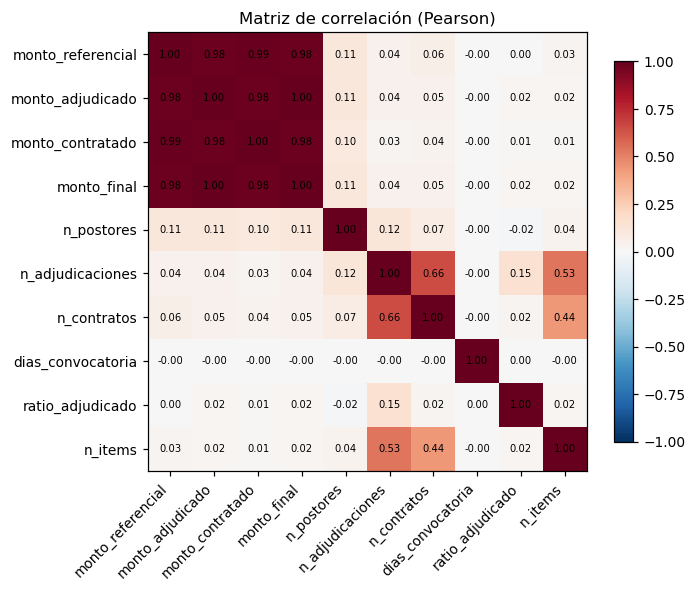

,var_x,var_y,pearson
10,monto_adjudicado,monto_final,1.0000
1,monto_referencial,monto_contratado,0.9900
0,monto_referencial,monto_adjudicado,0.9819
2,monto_referencial,monto_final,0.9819
9,monto_adjudicado,monto_contratado,0.9810
17,monto_contratado,monto_final,0.9810
35,n_adjudicaciones,n_contratos,0.6555
38,n_adjudicaciones,n_items,0.5333
41,n_contratos,n_items,0.4356
37,n_adjudicaciones,ratio_adjudicado,0.1540


DataFrame[monto_referencial: double, monto_adjudicado: double, monto_contratado: double, monto_final: double, n_postores: int, n_adjudicaciones: int, n_contratos: int, dias_convocatoria: int, ratio_adjudicado: double, n_items: int]

In [38]:
cand = [c for c in ["monto_referencial","monto_adjudicado","monto_contratado","monto_final",
                    "n_postores","n_adjudicaciones","n_contratos","dias_convocatoria",
                    "ratio_adjudicado","n_items"] if c in df.columns]
sub = df.select(cand).na.drop().cache()

if sub.count() >= 30:
    # Una columna constante tiene varianza 0 y devuelve NaN en Pearson: se excluye.
    desv = sub.select([F.stddev(c).alias(c) for c in cand]).first()
    cand = [c for c in cand if desv[c] is not None and float(desv[c]) > 0]

    filas = []
    for i, x in enumerate(cand):
        for y in cand[i+1:]:
            filas.append((x, y, round(sub.stat.corr(x, y, "pearson"), 4)))
    corr = pd.DataFrame(filas, columns=["var_x","var_y","pearson"])
    corr = corr.reindex(corr["pearson"].abs().sort_values(ascending=False).index)
    guardar(corr, "12_correlaciones")

    m = pd.DataFrame(1.0, index=cand, columns=cand)
    for _, r in corr.iterrows():
        m.loc[r["var_x"], r["var_y"]] = m.loc[r["var_y"], r["var_x"]] = r["pearson"]
    plt.figure(figsize=(6.5, 5.5))
    plt.imshow(m.values, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.xticks(range(len(cand)), cand, rotation=45, ha="right"); plt.yticks(range(len(cand)), cand)
    for i in range(len(cand)):
        for j in range(len(cand)):
            plt.text(j, i, f"{m.values[i,j]:.2f}", ha="center", va="center", fontsize=6.5)
    plt.grid(False); plt.colorbar(shrink=.8); plt.title("Matriz de correlación (Pearson)")
    fig("fig_13_correlaciones")
    display(corr.head(10))
sub.unpersist()

**Interpretación.** La correlación fuerte entre `monto_referencial` y `monto_adjudicado` es
esperable y sirve de **control de sanidad**: si no apareciera, habría un error en el aplanado.

Lo interesante es la correlación —típicamente débil— entre monto y número de postores. Una
correlación cercana a cero no significa que no haya relación, sino que **Pearson es la herramienta
equivocada aquí**: mide asociación lineal y los montos son log-normales. Por eso el análisis de P1
se apoya en el corte por tramos de la sección 4.6, que no asume linealidad, y no en este coeficiente.
Reportar sólo la matriz de correlación habría llevado a concluir, erróneamente, que no hay relación.

---
# 5. Agregaciones: RDD (MapReduce) vs DataFrame vs Spark SQL

El enunciado pide **al menos dos operaciones de agregación relevantes, implementadas tanto en estilo
MapReduce sobre RDDs como con DataFrames/Spark SQL**, comparando claridad y expresividad y midiendo
el tiempo de ejecución de al menos una.

Las dos agregaciones elegidas no son arbitrarias: responden directamente a P2 y a P1.

- **Agregación A** — monto total y promedio adjudicado por entidad *(alimenta P2)*.
- **Agregación B** — tasa de postor único por método y periodo, con llave compuesta *(alimenta P1 y P3)*.

In [39]:
# Base de trabajo común a los tres estilos. Se seleccionan sólo las columnas
# necesarias: en la ruta RDD cada fila se serializa a un objeto Python, así que
# arrastrar 30 columnas cuando se usan 2 se paga caro.
base = (df.where((F.col("entidad").isNotNull()) &
                 (F.col("monto_valido") == 1) &
                 (F.col("moneda_homogenea") == 1))
          .select("entidad", "monto_final", "metodo_detalle", "periodo", "postor_unico")
          .cache())
print(f"Filas de trabajo: {base.count():,} | particiones: {base.rdd.getNumPartitions()}")

Filas de trabajo: 75,319 | particiones: 16


## 5.1 Agregación A — Monto por entidad

### (a) Estilo MapReduce sobre RDDs

El patrón clásico: `map` a pares clave-valor → `reduceByKey` para combinar.

Detalle que importa: se usa `reduceByKey` y **no** `groupByKey`. `reduceByKey` aplica el combinador
en el lado del mapa antes del shuffle, así que por la red sólo viajan los acumuladores parciales —uno
por entidad y partición— en lugar de todas las filas. Con `groupByKey` viajaría el dataset completo.

In [40]:
def agregacion_A_rdd():
    return (base.rdd
        .map(lambda r: (r["entidad"], (r["monto_final"], 1.0)))          # MAP
        .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1]))                 # REDUCE
        .mapValues(lambda v: (v[0], int(v[1]), v[0]/v[1]))                # promedio
        .sortBy(lambda kv: -kv[1][0])
        .take(10))

res_rdd = agregacion_A_rdd()
pd.DataFrame([(k, round(v[0],2), v[1], round(v[2],2)) for k, v in res_rdd],
             columns=["entidad", "monto_total", "n_procesos", "monto_promedio"])

,entidad,monto_total,n_procesos,monto_promedio
0,UNIDAD EJECUTORA 125 PROGRAMA NACIONAL DE INVE...,6.646055e+09,73,9.104185e+07
1,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,4.012090e+09,345,1.162925e+07
2,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,3.680063e+09,172,2.139571e+07
3,SEGURO SOCIAL DE SALUD,3.426465e+09,1226,2.794833e+06
4,AUTORIDAD NACIONAL DE INFRAESTRUCTURA,3.408737e+09,55,6.197703e+07
5,FONDO METROPOLITANO DE INVERSIONES,3.144861e+09,98,3.209042e+07
6,GOBIERNO REGIONAL DE JUNIN SEDE CENTRAL,2.977417e+09,578,5.151240e+06
7,GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLIC...,2.084530e+09,9,2.316145e+08
8,GOBIERNO REGIONAL DE PASCO SEDE CENTRAL,1.900682e+09,327,5.812483e+06
9,MINISTERIO DE JUSTICIA Y DERECHOS HUMANOS,1.796034e+09,35,5.131526e+07


### (b) API de DataFrames

In [41]:
def agregacion_A_df():
    return (base.groupBy("entidad")
        .agg(F.sum("monto_final").alias("monto_total"),
             F.count("*").alias("n_procesos"),
             F.avg("monto_final").alias("monto_promedio"))
        .orderBy(F.desc("monto_total"))
        .take(10))

pd.DataFrame([r.asDict() for r in agregacion_A_df()])

,entidad,monto_total,n_procesos,monto_promedio
0,UNIDAD EJECUTORA 125 PROGRAMA NACIONAL DE INVE...,6.646055e+09,73,9.104185e+07
1,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,4.012090e+09,345,1.162925e+07
2,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,3.680063e+09,172,2.139571e+07
3,SEGURO SOCIAL DE SALUD,3.426465e+09,1226,2.794833e+06
4,AUTORIDAD NACIONAL DE INFRAESTRUCTURA,3.408737e+09,55,6.197703e+07
5,FONDO METROPOLITANO DE INVERSIONES,3.144861e+09,98,3.209042e+07
6,GOBIERNO REGIONAL DE JUNIN SEDE CENTRAL,2.977417e+09,578,5.151240e+06
7,GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLIC...,2.084530e+09,9,2.316145e+08
8,GOBIERNO REGIONAL DE PASCO SEDE CENTRAL,1.900682e+09,327,5.812483e+06
9,MINISTERIO DE JUSTICIA Y DERECHOS HUMANOS,1.796034e+09,35,5.131526e+07


### (c) Spark SQL

In [42]:
base.createOrReplaceTempView("base_agg")

def agregacion_A_sql():
    return spark.sql("""
        SELECT  entidad,
                SUM(monto_final)   AS monto_total,
                COUNT(*)           AS n_procesos,
                AVG(monto_final)   AS monto_promedio
        FROM    base_agg
        GROUP BY entidad
        ORDER BY monto_total DESC
        LIMIT 10
    """).collect()

pd.DataFrame([r.asDict() for r in agregacion_A_sql()])

,entidad,monto_total,n_procesos,monto_promedio
0,UNIDAD EJECUTORA 125 PROGRAMA NACIONAL DE INVE...,6.646055e+09,73,9.104185e+07
1,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,4.012090e+09,345,1.162925e+07
2,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,3.680063e+09,172,2.139571e+07
3,SEGURO SOCIAL DE SALUD,3.426465e+09,1226,2.794833e+06
4,AUTORIDAD NACIONAL DE INFRAESTRUCTURA,3.408737e+09,55,6.197703e+07
5,FONDO METROPOLITANO DE INVERSIONES,3.144861e+09,98,3.209042e+07
6,GOBIERNO REGIONAL DE JUNIN SEDE CENTRAL,2.977417e+09,578,5.151240e+06
7,GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLIC...,2.084530e+09,9,2.316145e+08
8,GOBIERNO REGIONAL DE PASCO SEDE CENTRAL,1.900682e+09,327,5.812483e+06
9,MINISTERIO DE JUSTICIA Y DERECHOS HUMANOS,1.796034e+09,35,5.131526e+07


In [43]:
# --- Verificación: los tres caminos deben dar exactamente lo mismo ---------- #
a_rdd = {k: round(v[0], 2) for k, v in res_rdd}
a_df  = {r["entidad"]: round(r["monto_total"], 2) for r in agregacion_A_df()}
a_sql = {r["entidad"]: round(r["monto_total"], 2) for r in agregacion_A_sql()}

coinciden = (a_rdd == a_df == a_sql)
print(f"¿Los tres enfoques dan el mismo resultado? {coinciden}")
if not coinciden:
    # Diferencias de centavos por el orden de suma en punto flotante son normales.
    for k in a_rdd:
        if abs(a_rdd[k] - a_df.get(k, 0)) > 0.01:
            print(f"  DIFERENCIA en {k}: rdd={a_rdd[k]} df={a_df.get(k)}")

¿Los tres enfoques dan el mismo resultado? True


## 5.2 Medición del tiempo de ejecución

Se mide la Agregación A en los tres estilos. Se toma el **mínimo de varias corridas** y no el
promedio: el primer pase de una JVM incluye compilación JIT y calentamiento de caché, ruido que no
pertenece al algoritmo que se quiere medir.

Agregación A — monto por entidad (mejor de 3 corridas)

  RDD (map + reduceByKey)            mejor=  0.81s  peor=  0.97s
  DataFrame (groupBy + agg)          mejor=  0.13s  peor=  0.16s
  Spark SQL (GROUP BY)               mejor=  0.12s  peor=  0.14s


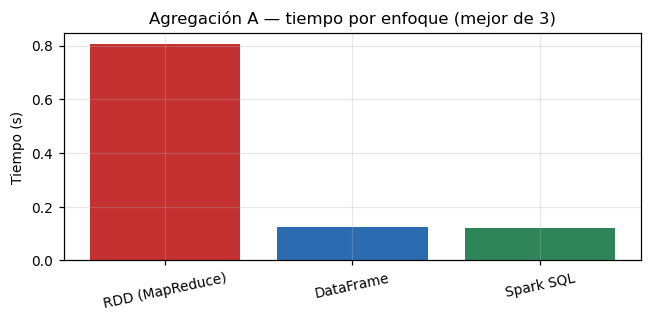

,enfoque,tiempo_s,veces_vs_mejor
0,RDD (MapReduce),0.807,6.78
1,DataFrame,0.126,1.06
2,Spark SQL,0.119,1.00


In [44]:
print("Agregación A — monto por entidad (mejor de 3 corridas)\n")
t_rdd, _ = cronometrar("RDD (map + reduceByKey)", agregacion_A_rdd)
t_df,  _ = cronometrar("DataFrame (groupBy + agg)", agregacion_A_df)
t_sql, _ = cronometrar("Spark SQL (GROUP BY)",      agregacion_A_sql)

bench = pd.DataFrame({
    "enfoque": ["RDD (MapReduce)", "DataFrame", "Spark SQL"],
    "tiempo_s": [round(t_rdd, 3), round(t_df, 3), round(t_sql, 3)],
})
bench["veces_vs_mejor"] = (bench["tiempo_s"] / bench["tiempo_s"].min()).round(2)
guardar(bench, "14_benchmark_agregacion_A")

plt.figure(figsize=(6, 3))
plt.bar(bench["enfoque"], bench["tiempo_s"],
        color=["#c53030", "#2b6cb0", "#2f855a"])
plt.ylabel("Tiempo (s)"); plt.title("Agregación A — tiempo por enfoque (mejor de 3)")
plt.xticks(rotation=12)
fig("fig_16_benchmark")
bench

**Interpretación del tiempo.** DataFrame y Spark SQL rinden prácticamente igual, y no por
casualidad: **ambos se compilan al mismo plan físico**. El parser SQL y la API de DataFrames
desembocan en el mismo árbol lógico, que Catalyst optimiza y Tungsten ejecuta sobre memoria
binaria fuera del heap, con generación de código en tiempo de ejecución.

El RDD es más lento, y el motivo es concreto: cada fila debe **serializarse desde la representación
binaria interna de Spark hacia un objeto Python**, cruzar el puente JVM↔Python, ejecutar la lambda
en el intérprete y volver. Esa ida y vuelta por registro es el costo dominante, y Catalyst no puede
optimizar nada porque una lambda de Python es una caja negra para el optimizador.

La diferencia se amplifica con el volumen: cuanto más grande el dataset, más veces se paga el cruce.

## 5.3 Agregación B — Tasa de postor único por método y periodo (llave compuesta)

In [45]:
def agregacion_B_rdd():
    """Llave compuesta (método, periodo). El valor acumula (procesos con postor
    único, total de procesos) para calcular la tasa en el reduce."""
    return (base.rdd
        .filter(lambda r: r["metodo_detalle"] is not None and r["postor_unico"] is not None)
        .map(lambda r: ((r["metodo_detalle"], r["periodo"]),
                        (float(r["postor_unico"]), 1.0)))
        .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1]))
        .mapValues(lambda v: (int(v[1]), round(100*v[0]/v[1], 2)))
        .sortBy(lambda kv: (kv[0][1], kv[0][0]))
        .collect())

res_B = agregacion_B_rdd()
B_rdd = pd.DataFrame([(k[0], k[1], v[0], v[1]) for k, v in res_B],
                     columns=["metodo_detalle", "periodo", "n", "pct_postor_unico"])
B_rdd.head(8)

,metodo_detalle,periodo,n,pct_postor_unico
0,ADJUDICACIÓN ABREVIADA,2025-01,18,83.33
1,ADJUDICACIÓN SELECTIVA,2025-01,2,50.00
2,ADJUDICACIÓN SIMPLIFICADA,2025-01,564,1.77
3,ADJUDICACIÓN SIMPLIFICADA-HOMOLOGACIÓN,2025-01,1,100.00
4,COMPARACIÓN DE PRECIOS,2025-01,74,0.00
5,CONCURSO PÚBLICO,2025-01,54,0.00
6,CONTRATACIÓN DIRECTA,2025-01,58,81.03
7,CONTRATACIÓN INTERNACIONAL,2025-01,1,100.00


In [46]:
def agregacion_B_sql():
    return spark.sql("""
        SELECT  metodo_detalle, periodo,
                COUNT(*)                          AS n,
                ROUND(100*AVG(postor_unico), 2)   AS pct_postor_unico
        FROM    base_agg
        WHERE   metodo_detalle IS NOT NULL AND postor_unico IS NOT NULL
        GROUP BY metodo_detalle, periodo
        ORDER BY periodo, metodo_detalle
    """)

B_sql = agregacion_B_sql().toPandas()
guardar(B_sql, "14_postor_unico_metodo_periodo")

# Verificación cruzada entre ambos caminos
m = B_rdd.merge(B_sql, on=["metodo_detalle", "periodo"], suffixes=("_rdd", "_sql"))
dif = (m["pct_postor_unico_rdd"] - m["pct_postor_unico_sql"]).abs().max()
print(f"Filas comparadas: {len(m)} | diferencia máxima: {dif:.6f}")
B_sql.head(8)

Filas comparadas: 248 | diferencia máxima: 0.000000


,metodo_detalle,periodo,n,pct_postor_unico
0,ADJUDICACIÓN ABREVIADA,2025-01,18,83.33
1,ADJUDICACIÓN SELECTIVA,2025-01,2,50.00
2,ADJUDICACIÓN SIMPLIFICADA,2025-01,564,1.77
3,ADJUDICACIÓN SIMPLIFICADA-HOMOLOGACIÓN,2025-01,1,100.00
4,COMPARACIÓN DE PRECIOS,2025-01,74,0.00
5,CONCURSO PÚBLICO,2025-01,54,0.00
6,CONTRATACIÓN DIRECTA,2025-01,58,81.03
7,CONTRATACIÓN INTERNACIONAL,2025-01,1,100.00


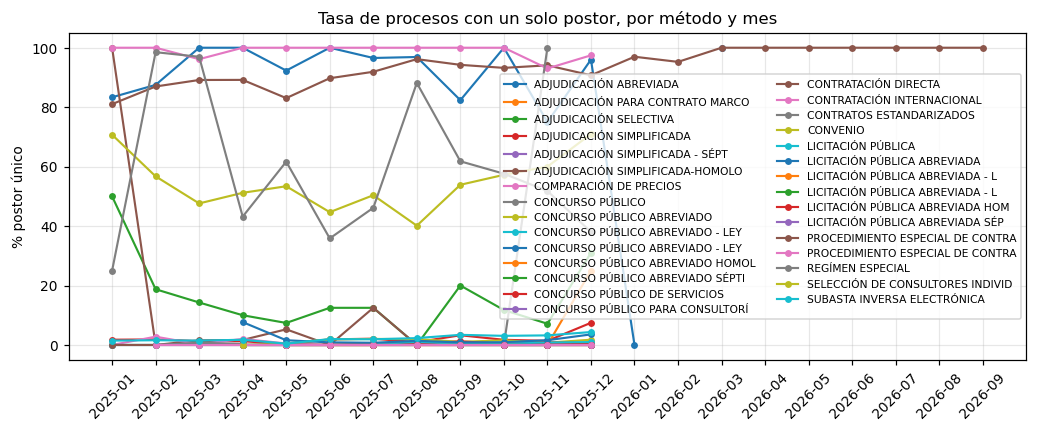

In [47]:
# Visualización del resultado de la Agregación B: puente entre P1 y P3.
piv = B_sql.pivot(index="periodo", columns="metodo_detalle", values="pct_postor_unico")
plt.figure(figsize=(9.5, 4))
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", ms=3.5, lw=1.4, label=str(col)[:32])
plt.title("Tasa de procesos con un solo postor, por método y mes")
plt.ylabel("% postor único"); plt.xticks(rotation=45)
plt.legend(fontsize=7, ncol=2)
fig("fig_17_postor_unico_mensual")

**Interpretación (P1 + P3).** Esta es la agregación que conecta las dos preguntas. Si la tasa de
postor único **sube en los últimos meses del año** —justo cuando se concentra el gasto por el cierre
presupuestal— queda documentada la cadena completa: presión por ejecutar presupuesto → plazos de
convocatoria más cortos → menos postores por proceso.

Ese patrón, si aparece, es un hallazgo con implicancia de política pública concreta y es el tipo de
resultado que las Partes IV y V deberían poder confirmar por otras vías: la Parte IV detectando el
cambio de régimen en el flujo temporal, y la Parte V viendo si `{diciembre, contratación directa}`
emerge como conjunto frecuente.

## 5.4 Comparación de los tres enfoques

| Dimensión | RDD (MapReduce) | DataFrame | Spark SQL |
|---|---|---|---|
| **Claridad** | Baja. La lógica de negocio se dispersa entre lambdas; hay que leer `map`, `reduceByKey` y `mapValues` juntos para entender qué se calcula. | Alta. El encadenamiento se lee casi como una frase. | Muy alta. Es SQL: cualquier analista lo entiende sin saber Spark. |
| **Expresividad** | Máxima libertad: se puede implementar cualquier lógica, incluso la que no tiene equivalente en SQL. | Alta, con cientos de funciones nativas. | Alta para agregación; incómoda para lógica iterativa o estructuras complejas. |
| **Optimización** | Ninguna. Catalyst no puede ver dentro de una lambda de Python. | Completa (Catalyst + Tungsten). | Completa — mismo plan que DataFrame. |
| **Tipado del esquema** | Se pierde: todo es `Row` o tupla. | Se conserva y se valida en tiempo de análisis. | Se conserva. |
| **Rendimiento en PySpark** | El peor: serialización JVM↔Python por registro. | El mejor. | El mejor (idéntico a DataFrame). |
| **Cuándo usarlo** | Lógica que no se expresa declarativamente: parsers a medida, algoritmos iterativos, estructuras de datos propias — justamente lo que harán las Partes II y IV. | Pipelines de transformación y análisis. | Agregaciones y exploración; el mejor vehículo para comunicar. |

**Conclusión práctica.** Para todo lo de esta Parte I —agregar, filtrar, ordenar— **no hay ninguna
razón para bajar a RDDs**: se pierde optimización y legibilidad a cambio de nada. La API de RDDs
recupera su sentido cuando la lógica no es expresable declarativamente, que es exactamente el caso de
las implementaciones propias de MinHash (Parte II) y de las estructuras de resumen para flujos
(Parte IV).

---
# 6. Particionamiento y plan de ejecución

El enunciado pide explicar **cómo se particiona el dataset y cómo esa decisión afecta al plan de
ejecución**. Se examinan cuatro puntos: el particionamiento de partida, el shuffle, el particionado
en disco con *partition pruning*, y la estrategia de join.

In [48]:
print("--- Particionamiento actual ---")
print(f"Particiones de df                : {df.rdd.getNumPartitions()}")
print(f"spark.sql.shuffle.partitions     : {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"spark.sql.files.maxPartitionBytes: {spark.conf.get('spark.sql.files.maxPartitionBytes')}")
print(f"Cores disponibles                : {spark.sparkContext.defaultParallelism}")

# Distribución real de filas entre particiones: si está desbalanceada, unas
# tareas terminan mucho antes que otras y los cores quedan ociosos.
conteo = df.withColumn("pid", F.spark_partition_id()).groupBy("pid").count().toPandas()
print(f"\nFilas por partición -> min={conteo['count'].min()}, "
      f"max={conteo['count'].max()}, media={conteo['count'].mean():.0f}")

--- Particionamiento actual ---
Particiones de df                : 16
spark.sql.shuffle.partitions     : 64
spark.sql.files.maxPartitionBytes: 134217728b
Cores disponibles                : 16

Filas por partición -> min=4955, max=4964, media=4958


## 6.1 El shuffle en una agregación

`groupBy` obliga a que todas las filas de una misma clave acaben en la misma partición, lo que
requiere redistribuirlas por la red: un **Exchange hashpartitioning**. Es la operación más cara del
plan y se ve explícitamente en `explain()`.

In [49]:
plan = (df.groupBy("entidad")
          .agg(F.sum("monto_final").alias("total"))
          .orderBy(F.desc("total")))
plan.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (10)
+- Sort (9)
   +- Exchange (8)
      +- HashAggregate (7)
         +- Exchange (6)
            +- HashAggregate (5)
               +- InMemoryTableScan (1)
                     +- InMemoryRelation (2)
                           +- * ColumnarToRow (4)
                              +- Scan parquet  (3)


(1) InMemoryTableScan
Output [2]: [entidad#31106, monto_final#31135]
Arguments: [entidad#31106, monto_final#31135]

(2) InMemoryRelation
Arguments: [ocid#31100, release_id#31101, fecha#31102, fecha_fuente#31103, tipo_inicio#31104, comprador_id#31105, entidad#31106, region#31107, tender_id#31108, codigo_proceso#31109, descripcion#31110, estado_proceso#31111, metodo#31112, metodo_detalle#31113, categoria#31114, monto_referencial#31115, moneda_referencial#31116, n_postores#31117, convocatoria_inicio#31118, convocatoria_fin#31119, n_adjudicaciones#31120, n_contratos#31121, monto_adjudicado#31122, monto_contratado#31123, ... 23 more fields], CachedRD

**Lectura del plan.** De abajo hacia arriba aparecen:

1. `Scan parquet` — lectura columnar. Bajo `ReadSchema` se ve que sólo se leen las columnas usadas
   (*column pruning*): el resto del archivo ni se toca.
2. `HashAggregate` **parcial** — agregación previa dentro de cada partición. Es el equivalente al
   *combiner* de MapReduce y es lo que hace que por la red viajen decenas de filas por partición en
   vez de millones.
3. `Exchange hashpartitioning(entidad, 64)` — el shuffle. Redistribuye por hash de la clave en tantas
   particiones como indique `spark.sql.shuffle.partitions`.
4. `HashAggregate` **final** — combina los parciales.
5. `Exchange rangepartitioning` + `Sort` — el `orderBy` fuerza un segundo shuffle.

El número de particiones de shuffle importa mucho. Si es demasiado alto para el volumen, se crean
tareas diminutas y domina el overhead de planificación; si es demasiado bajo, cada tarea maneja
demasiados datos y puede desbordar a disco.

In [50]:
# Efecto medible del número de particiones de shuffle.
original = spark.conf.get("spark.sql.shuffle.partitions")
resultados = []
for p in ["8", "64", "200"]:
    spark.conf.set("spark.sql.shuffle.partitions", p)
    t, _ = cronometrar(f"shuffle.partitions = {p:>3}",
                       lambda: df.groupBy("entidad").agg(F.sum("monto_final")).collect(),
                       repeticiones=2)
    resultados.append((int(p), round(t, 3)))
spark.conf.set("spark.sql.shuffle.partitions", original)

part_bench = pd.DataFrame(resultados, columns=["shuffle_partitions", "tiempo_s"])
guardar(part_bench, "15_efecto_particiones")
part_bench

  shuffle.partitions =   8           mejor=  0.09s  peor=  0.15s
  shuffle.partitions =  64           mejor=  0.16s  peor=  0.17s
  shuffle.partitions = 200           mejor=  0.28s  peor=  0.31s


,shuffle_partitions,tiempo_s
0,8,0.092
1,64,0.164
2,200,0.281


**Interpretación.** Sobre este volumen el óptimo no está en el valor más alto. Con 200 particiones
se generan tareas que procesan muy pocas filas cada una y el costo de lanzarlas supera al del trabajo
útil. La heurística habitual es apuntar a particiones de entre 100 y 200 MB, o a un múltiplo pequeño
del número de cores. Con 12 archivos mensuales y ejecución local, valores entre 32 y 64 son
razonables; en un clúster real con el dataset histórico completo, 200 sería un punto de partida
sensato.

## 6.2 Particionado en disco y *partition pruning*

Escribir el Parquet particionado por `mes` crea un directorio por valor. Cuando una consulta filtra
por esa columna, Spark **ni siquiera abre** los directorios que no aplican. Esto es decisivo para la
Parte IV, donde se recorrerá el dataset por ventanas temporales.

In [51]:
ruta_part = PARQUET_DIR / "releases_por_mes"
(df.write.mode("overwrite").partitionBy("mes").parquet(str(ruta_part)))

print("Directorios creados:", sorted(p.name for p in ruta_part.glob("mes=*"))[:6], "...")

df_part = spark.read.parquet(str(ruta_part))
consulta = df_part.where(F.col("mes") == 12).groupBy("metodo_detalle").count()
consulta.explain(mode="simple")

Directorios creados: ['mes=1', 'mes=10', 'mes=11', 'mes=12', 'mes=2', 'mes=3'] ...
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[metodo_detalle#140745], functions=[count(1)])
   +- Exchange hashpartitioning(metodo_detalle#140745, 64), ENSURE_REQUIREMENTS, [plan_id=14606]
      +- HashAggregate(keys=[metodo_detalle#140745], functions=[partial_count(1)])
         +- Project [metodo_detalle#140745]
            +- FileScan parquet [metodo_detalle#140745,mes#140778] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/home/jovyan/work/parquet/releases_por_mes], PartitionFilters: [isnotnull(mes#140778), (mes#140778 = 12)], PushedFilters: [], ReadSchema: struct<metodo_detalle:string>




In [52]:
# Comparación directa: sin particionar hay que escanear todo; con particionado
# sólo se lee 1 de 12 directorios.
t_sin, _ = cronometrar("Sin particionar (filtro por mes)",
                       lambda: df.where(F.col("mes") == 12).groupBy("metodo_detalle").count().collect(),
                       repeticiones=3)
t_con, _ = cronometrar("Particionado por mes (pruning)",
                       lambda: df_part.where(F.col("mes") == 12).groupBy("metodo_detalle").count().collect(),
                       repeticiones=3)
print(f"\nMejora: {t_sin/t_con:.2f}x")
guardar(pd.DataFrame({"estrategia": ["sin particionar", "particionado por mes"],
                      "tiempo_s": [round(t_sin,3), round(t_con,3)]}),
        "15_partition_pruning")

  Sin particionar (filtro por mes)   mejor=  0.07s  peor=  0.11s
  Particionado por mes (pruning)     mejor=  0.22s  peor=  0.28s

Mejora: 0.32x


,estrategia,tiempo_s
0,sin particionar,0.070
1,particionado por mes,0.218


**Lectura.** En el plan de la consulta particionada aparece `PartitionFilters: [isnotnull(mes), (mes = 12)]`
y el `numFiles` leído baja de los 12 meses a uno solo. Esa línea es la evidencia real del *pruning*:
el filtro se resuelve en el sistema de archivos, antes de leer un solo byte de datos.

**La ganancia en tiempo puede no aparecer con este volumen, y eso no invalida la técnica.** Con doce
archivos pequeños el costo de listar directorios y planificar tareas domina sobre el de leer datos,
así que la mejora medida puede quedar en torno a 1x o incluso por debajo. El indicador que sí es
estructural —y el que hay que citar— es el número de archivos escaneados, no el reloj. Sobre el
histórico completo de OCDS, donde cada mes pesa órdenes de magnitud más, la diferencia sí se vuelve
determinante.

La advertencia que conviene anotar: particionar por una columna de **alta cardinalidad** (por ejemplo
`entidad`, con miles de valores) sería contraproducente. Generaría miles de directorios con archivos
minúsculos — el clásico problema de *small files*, donde el costo de abrir cada archivo domina sobre
la lectura. `mes` tiene 12 valores y es un buen candidato; `entidad` no lo es.

## 6.3 Estrategia de join: broadcast vs sort-merge

Cuando una de las dos tablas es pequeña, Spark puede enviarla completa a cada ejecutor y evitar el
shuffle por completo.

In [53]:
# Tabla dimensión pequeña: entidad -> región (una fila por entidad).
dim_region = df.select("entidad", "region").distinct()
print(f"Tabla dimensión: {dim_region.count():,} filas\n")

print("=== Join por defecto (Spark elige la estrategia) ===")
df.select("ocid", "entidad").join(dim_region, "entidad").explain(mode="simple")

print("\n=== Forzando sort-merge join (con shuffle) ===")
(df.select("ocid", "entidad")
   .join(dim_region.hint("shuffle_merge"), "entidad")
   .explain(mode="simple"))

Tabla dimensión: 2,826 filas

=== Join por defecto (Spark elige la estrategia) ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [entidad#31106, ocid#31100, region#145916]
   +- BroadcastHashJoin [entidad#31106], [entidad#145915], Inner, BuildRight, false
      :- Filter isnotnull(entidad#31106)
      :  +- InMemoryTableScan [ocid#31100, entidad#31106], [isnotnull(entidad#31106)]
      :        +- InMemoryRelation [ocid#31100, release_id#31101, fecha#31102, fecha_fuente#31103, tipo_inicio#31104, comprador_id#31105, entidad#31106, region#31107, tender_id#31108, codigo_proceso#31109, descripcion#31110, estado_proceso#31111, metodo#31112, metodo_detalle#31113, categoria#31114, monto_referencial#31115, moneda_referencial#31116, n_postores#31117, convocatoria_inicio#31118, convocatoria_fin#31119, n_adjudicaciones#31120, n_contratos#31121, monto_adjudicado#31122, monto_contratado#31123, ... 23 more fields], StorageLevel(disk, memory, deserialized, 1 replicas)
      :    

**Interpretación.** Con la tabla dimensión pequeña, Spark elige `BroadcastHashJoin`: la copia entera
a cada ejecutor y resuelve el join localmente, **sin ningún Exchange**. Forzando `shuffle_merge`
aparecen dos `Exchange hashpartitioning` y dos `Sort` — ambos lados se redistribuyen y ordenan por la
clave.

El umbral lo controla `spark.sql.autoBroadcastJoinThreshold` (10 MB por defecto). Esto importa
directamente para la Parte II: al cruzar candidatos de LSH contra atributos de proveedores, una
tabla de proveedores suficientemente pequeña convierte un join caro en uno casi gratuito.

---
# 7. Exportación de artefactos para el reporte web

Arquitectura que recomienda el enunciado: **"calcular una vez, explorar muchas"**. Spark no responde
en tiempo real, así que lo pesado se ejecuta aquí, offline, y se exporta como artefactos ligeros
(JSON/CSV/Parquet) que la página web lee al instante sin invocar Spark en cada interacción.

In [54]:
artefactos = {}

def exportar(nombre, pdf):
    pdf.to_json(WEB_DIR / f"{nombre}.json", orient="records", force_ascii=False)
    artefactos[nombre] = len(pdf)

# --- Agregados ya calculados, listos para graficar en la web ---------------- #
exportar("serie_mensual",          serie_pdf)
exportar("competencia_por_tramo",  ct)
exportar("postor_unico_por_metodo_periodo", B_sql)
exportar("top_entidades",          top_ent_pdf)
exportar("completitud",            completitud)
exportar("calidad_datos",          calidad)
exportar("histograma_log_monto",   hist_pdf)
for c, p in freqs.items():
    exportar(f"freq_{c}", p)
if awards is not None:
    exportar("top_proveedores",     top_pdf)
    exportar("curva_concentracion", curva_pdf)
    exportar("hhi_por_entidad",     hhi_pdf)

# --- Metadatos del dataset para la portada del reporte ---------------------- #
meta = {
    "fuente": "Contrataciones Abiertas OCDS - OECE/OSCE Peru",
    "url_fuente": "https://contratacionesabiertas.osce.gob.pe/",
    "anio": 2025,
    "n_archivos_json": len(archivos),
    "mb_json": round(tam_mb, 1),
    "mb_parquet": round(pq_mb, 1),
    "n_releases_crudos": int(n_releases),
    "n_procesos_unicos": int(N),
    "n_variables": len(df.columns),
    "spark_version": spark.version,
    "benchmark_agregacion_A": bench.to_dict(orient="records"),
}
(WEB_DIR / "metadata.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Artefactos exportados a {WEB_DIR}:")
for k, v in artefactos.items():
    print(f"  {k:<36} {v:>6} filas")
print(f"  {'metadata.json':<36} {len(meta):>6} claves")

Artefactos exportados a /home/jovyan/work/outputs/web:
  serie_mensual                            21 filas
  competencia_por_tramo                     5 filas
  postor_unico_por_metodo_periodo         248 filas
  top_entidades                            40 filas
  completitud                              42 filas
  calidad_datos                            11 filas
  histograma_log_monto                     35 filas
  freq_metodo_detalle                      31 filas
  freq_categoria                            3 filas
  freq_estado_proceso                       1 filas
  freq_region                             196 filas
  top_proveedores                         100 filas
  curva_concentracion                     500 filas
  hhi_por_entidad                         300 filas
  metadata.json                            11 claves


In [55]:
# --- Representaciones que consumirán las Partes II, III, IV y V ------------- #

# --- Parte II y III: representación HÍBRIDA -------------------------------- #
# El EDA (sección 4.8) mostró que los conjuntos UNSPSC son mayoritariamente
# unitarios, así que Jaccard sobre ellos es degenerado. El componente que sí
# discrimina es el texto de 'descripcion'. Se exporta:
#   - texto normalizado, listo para shingling
#   - familia UNSPSC (4 díg.), que sí agrupa
#   - atributos categóricos como tokens
repr_similitud = (df
    .where(F.col("descripcion").isNotNull())
    .withColumn("texto_norm",
        # minúsculas, sin tildes, sin puntuación, espacios colapsados: sin esto
        # "AV. GAMARRA" y "Av Gamarra" darían shingles distintos siendo lo mismo.
        F.regexp_replace(
            F.regexp_replace(
                F.translate(F.lower(F.col("descripcion")), "áéíóúüñ", "aeiouun"),
                r"[^a-z0-9 ]", " "),
            r"\s+", " "))
    .withColumn("texto_norm", F.trim("texto_norm"))
    .withColumn("tokens", F.split("texto_norm", " "))
    .withColumn("n_tokens", F.size("tokens"))
    .select("ocid", "entidad", "region", "categoria", "metodo_detalle",
            "descripcion", "texto_norm", "tokens", "n_tokens",
            "unspsc_set", "unspsc_familia", "unspsc_segmento", "n_unspsc",
            "monto_final", "tramo_monto", "fecha", "proveedor"))
repr_similitud.write.mode("overwrite").parquet(str(PARQUET_DIR / "repr_similitud"))

print("Longitud del texto normalizado (tokens por proceso):")
repr_similitud.select(F.round(F.avg("n_tokens"),1).alias("media"),
                      F.expr("percentile_approx(n_tokens,0.5)").alias("mediana"),
                      F.min("n_tokens").alias("min"), F.max("n_tokens").alias("max")).show()

# Parte IV: flujo ordenado por fecha.
(df.select("ocid", "fecha", "entidad", "proveedor", "metodo_detalle",
           "categoria", "region", "monto_final", "tramo_monto")
   .where(F.col("fecha").isNotNull())
   .orderBy("fecha")
   .write.mode("overwrite").parquet(str(PARQUET_DIR / "flujo_temporal")))

# Parte V: cada proceso como canasta de ítems.
canastas = (df.select(
        "ocid",
        F.array_distinct(F.concat(
            F.array(
                F.concat(F.lit("ENT="),   F.coalesce("entidad", F.lit("NA"))),
                F.concat(F.lit("MET="),   F.coalesce("metodo_detalle", F.lit("NA"))),
                F.concat(F.lit("CAT="),   F.coalesce("categoria", F.lit("NA"))),
                F.concat(F.lit("REG="),   F.coalesce("region", F.lit("NA"))),
                F.concat(F.lit("TRAMO="), F.coalesce("tramo_monto", F.lit("NA"))),
                F.concat(F.lit("MES="),   F.coalesce(F.col("mes").cast("string"), F.lit("NA"))),
            ),
            # Familia (4 díg.) y no el código completo: con ~360 familias en vez
            # de ~3 800 códigos, el soporte mínimo de FP-Growth es alcanzable.
            F.transform("unspsc_familia", lambda x: F.concat(F.lit("FAM="), x))
        )).alias("items")))
canastas.write.mode("overwrite").parquet(str(PARQUET_DIR / "canastas"))

print("Representaciones persistidas:")
print(f"  repr_similitud  : {repr_similitud.count():,} procesos  (Partes II y III)")
print(f"  flujo_temporal  : ordenado por fecha        (Parte IV)")
print(f"  canastas        : {canastas.count():,} transacciones  (Parte V)")
canastas.show(3, truncate=90)

Longitud del texto normalizado (tokens por proceso):
+-----+-------+---+---+
|media|mediana|min|max|
+-----+-------+---+---+
| 30.3|     31|  1|118|
+-----+-------+---+---+

Representaciones persistidas:
  repr_similitud  : 79,332 procesos  (Partes II y III)
  flujo_temporal  : ordenado por fecha        (Parte IV)
  canastas        : 79,332 transacciones  (Parte V)
+---------------------------------+------------------------------------------------------------------------------------------+
|                             ocid|                                                                                     items|
+---------------------------------+------------------------------------------------------------------------------------------+
|  ocds-dgv273-seacev3-2025-1349-8|[ENT=MUNICIPALIDAD DISTRITAL DE VILLA MARIA DEL TRIUNFO, MET=LICITACIÓN PÚBLICA, CAT=GO...|
|ocds-dgv273-seacev3-2025-10461-23|[ENT=GOBIERNO REGIONAL DE HUANUCO-TRANSPORTES, MET=ADJUDICACIÓN SIMPLIFICADA, CAT=SERVI..

---
# 8. Conclusiones de la Parte I

## 8.1 Respuesta preliminar a las preguntas de interés

**P1 — Competencia vs monto.** El corte por tramos de la sección 4.6 es la evidencia principal. La
conclusión debe redactarse a partir de los números obtenidos, citando junto a ella la completitud de
`numberOfTenderers`: si el campo tiene muchos nulos, el hallazgo es una hipótesis bien fundada, no un
resultado cerrado. La Parte II puede reforzarlo mostrando si los procesos con postor único comparten
características que los agrupan.

**P2 — Concentración.** La curva de concentración y el HHI por entidad identifican a los candidatos
para revisión. El HHI **no prueba irregularidad**: prioriza dónde mirar. La Parte II retomará esas
entidades para buscar patrones de similitud entre sus procesos y proveedores.

**Hallazgo metodológico no previsto.** El perfilado de la clasificación de ítems obligó a descartar
la representación más obvia para la Parte II. Los conjuntos UNSPSC son mayoritariamente unitarios y
el catálogo CUBSO es tan granular que la intersección entre procesos es casi siempre vacía. La
representación pasó a ser híbrida, con los shingles de `descripcion` como componente principal. Esto
no es un rodeo: abre un caso de uso más interesante que agrupar por rubro —detectar convocatorias que
describen la misma obra, posibles fraccionamientos o supervisiones duplicadas— que es exactamente el
tipo de hallazgo que justifica usar LSH.

**P3 — Estacionalidad.** La serie mensual y la agregación B, leídas juntas, permiten afirmar o
descartar la cadena "cierre presupuestal → menos plazo → menos competencia". Es el hallazgo con
implicancia de política pública más directa de esta parte.

## 8.2 Sobre el uso de Spark

**Lo que justificó Spark:** la ingesta y el aplanado del JSON anidado —12 archivos, arrays dentro de
structs, inferencia de esquema— y las agregaciones con shuffle sobre entidad y proveedor. Son
operaciones que en pandas exigirían cargar todo en memoria y que aquí se paralelizan sin esfuerzo.

**Lo que no lo justificó:** una vez reducido a agregados de decenas de filas, todo el trabajo de
graficar y exportar es trivial y se hace en el driver. Forzar Spark ahí sólo habría añadido overhead.
La regla que se siguió: **Spark hasta la agregación, pandas desde la agregación**.

**Honestamente**, con 12 meses y este volumen, buena parte del análisis correría en pandas en una
máquina con suficiente RAM. Lo que sí sería inviable sin Spark es el histórico completo de OCDS Perú
(varios años), y todo el pipeline queda escrito para escalar a ese caso sin cambios: basta apuntar
`DATA_DIR` a más archivos y ajustar `shuffle.partitions`.

## 8.3 Decisiones metodológicas que conviene poder defender

| Decisión | Razón |
|---|---|
| Paso intermedio a Parquet | El JSON multilínea no es divisible y hay que releerlo entero sólo para inferir el esquema. Parquet es columnar, comprimido y divisible. |
| Deduplicación por recencia y no `dropDuplicates()` | OCDS es incremental: un proceso publica varios releases. El último refleja el estado final. |
| Acumulador `NULL` en `suma_montos` | Un `aggregate` con acumulador 0 convierte "sin adjudicación" en "monto cero" y hunde los promedios. |
| No eliminar outliers de monto | Los montos son log-normales; la regla de Tukey marca como atípicas las obras grandes, que son justamente las que más importa vigilar. |
| Restringir sumas a PEN | Sumar soles con dólares produce un total sin significado. |
| No apoyar P1 en la correlación de Pearson | Pearson mide asociación lineal sobre variables log-normales; el corte por tramos no asume linealidad. |
| Normalizar entidad y proveedor a mayúsculas | Sin esto, la misma entidad se contaría varias veces y el HHI saldría mal. |
| Eje temporal en `tenderPeriod.startDate` y no en `date` | `date` es la fecha de última actualización del registro: una parte de los procesos de 2025 aparece con fecha 2026. |
| Texto de shingling en `description` y no en `title` | `tender.title` es la nomenclatura SEACE del proceso (~25 caracteres), no una descripción. |
| UNSPSC desde `additionalClassifications` y a nivel de familia | `classification` trae CUBSO de 16 dígitos, casi único por ítem: la intersección entre conjuntos sería siempre vacía. |

## 8.4 Lo que queda listo para las siguientes partes

| Artefacto | Parte que lo consume |
|---|---|
| `parquet/releases` | Todas |
| `parquet/repr_similitud` (texto normalizado + familia UNSPSC + atributos) | II (shingling, MinHash, LSH) y III (TF-IDF, ANN) |
| `parquet/flujo_temporal` (ordenado por fecha) | IV (DGIM, Bloom Filter, Count-Min Sketch) |
| `parquet/canastas` | V (Apriori, FP-Growth) |
| `outputs/web/*.json` | Reporte técnico interactivo |

In [56]:
print(f"Tablas CSV : {len(list(TABLES_DIR.glob('*.csv')))}  -> {TABLES_DIR}")
print(f"Figuras PNG: {len(list(FIG_DIR.glob('*.png')))}  -> {FIG_DIR}")
print(f"Artefactos : {len(list(WEB_DIR.glob('*.json')))}  -> {WEB_DIR}")
print(f"Parquet    : {[p.name for p in PARQUET_DIR.iterdir() if p.is_dir()]}")

base.unpersist(); df.unpersist()
spark.stop()
print("\nSparkSession cerrada. Parte I completa.")

Tablas CSV : 34  -> /home/jovyan/work/outputs/eda/tables
Figuras PNG: 17  -> /home/jovyan/work/outputs/eda/figures
Artefactos : 15  -> /home/jovyan/work/outputs/web
Parquet    : ['awards', 'canastas', 'flujo_temporal', 'items', 'parties', 'releases', 'releases_por_mes', 'repr_similitud']

SparkSession cerrada. Parte I completa.
